 # Аналіз платіжних транзакцій за 2022 рік


Аналіз платіжних транзакцій за 2022 рік: дослідження якості даних, ключових платіжних метрик, динаміки Success Rate, причин невдалих платежів та їхнього впливу на користувачів.

# Мета аналізу

Дослідити платіжний домен за 2022 рік, виявити ключові тренди та проблемні зони, визначити основні причини невдалих платежів і сформувати практичні рекомендації для покращення платіжного процесу.

## 1. Огляд та очищення даних

### Завантаження даних

Імпортуємо бібліотеки та завантажуємо датасет платіжних транзакцій.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [125]:
df = pd.read_csv('test_payment_data.csv')

**Структура датасету.** Перевіряємо назви колонок, типи даних і кількість заповнених значень.

In [126]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 566413 entries, 0 to 566412
Data columns (total 13 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   #                   566413 non-null  int64  
 1   order_id            566413 non-null  object 
 2   event_time          566413 non-null  object 
 3   user_id             566413 non-null  object 
 4   price               566413 non-null  float64
 5   payment_number      566413 non-null  object 
 6   transaction_status  566413 non-null  object 
 7   card_brand          566413 non-null  object 
 8   card_type           565643 non-null  object 
 9   bank_name           564404 non-null  object 
 10  error_type          313048 non-null  float64
 11  currency            566413 non-null  object 
 12  card_country        565886 non-null  object 
dtypes: float64(2), int64(1), object(10)
memory usage: 56.2+ MB


**Часовий період.** Перетворюємо `event_time` на формат дати й часу та перевіряємо межі періоду.

In [4]:
df['event_time'] = pd.to_datetime(df['event_time'])

In [5]:
print(df['event_time'].max())
print(df['event_time'].min())

2022-12-31 23:59:16
2022-01-01 00:00:36


**Перші записи.** Переглядаємо приклад даних перед очищенням.

In [6]:
df.head()

,#,order_id,event_time,user_id,price,payment_number,transaction_status,card_brand,card_type,bank_name,error_type,currency,card_country
0,1,c500aa10-30f8-4927-96c5-4e97b6afac83,2022-07-08 18:32:39,c1ed5188-caac-4d56-bad8-bc8ee0b09960,21.0,reccurent,fail,VISA,PREPAID,ADVANCED BANK OF ASIA LIMITED,3.08,USD,KHM
1,2,624d6f30-c1bc-4778-a23e-6a227bac73ac,2022-06-09 22:18:36,c9ff65b8-75e6-467f-8715-21edb5fd06af,36.0,reccurent,fail,VISA,PREPAID,UNITED BANK FOR AFRICA GHANA LIMITED,3.02,USD,GHA
2,3,4d75ca57-8883-49a9-b150-1ab7a47d12f8,2022-06-09 11:18:32,1005d4fb-1b7d-4715-835f-4d2a9bfe7cbb,36.0,initial,success,VISA,CREDIT,ICICI BANK LTD,NaN,USD,IND
3,4,3fd11eed-4236-46aa-8f21-3c1e1a17a1bc,2022-06-29 13:50:47,866c4b2b-0285-43aa-98bd-d60bc3a78d7c,36.0,reccurent,fail,VISA,DEBIT,THE TORONTO-DOMINION BANK,3.02,USD,CAN
4,5,3b19657f-1a34-4233-b25c-5d3b7fb32782,2022-06-17 15:16:47,bd2e4137-5526-4d9b-9dde-7482087fc321,9.0,reccurent,success,MASTERCARD,CREDIT,"CAPITAL ONE BANK (USA), NATIONAL ASSOCIATION",NaN,USD,USA


### Перевірка та видалення дублікатів

Перевіряємо повні дублікати й унікальність технічної колонки `#`. Після її видалення повторюємо перевірку та переглядаємо записи, що дублюються.

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
print(df['#'].nunique())
print(df.shape[0])

566413
566413


In [9]:
df = df.drop(columns='#')

In [10]:
df.duplicated().sum()

np.int64(1098)

In [11]:
df[df.duplicated(keep=False)].sort_values(by=['order_id', 'event_time']).head(4)

,order_id,event_time,user_id,price,payment_number,transaction_status,card_brand,card_type,bank_name,error_type,currency,card_country
28834,005b0d57-4270-4e8a-8476-d71bbf4448bd,2022-12-09 16:57:50,7cd492f9-dda6-4fa9-9d28-00784258feaf,36.0,reccurent,success,MASTERCARD,CREDIT,INDUSTRIAL AND COMMERCIAL BANK OF CHINA (ARGEN...,NaN,USD,ARG
97588,005b0d57-4270-4e8a-8476-d71bbf4448bd,2022-12-09 16:57:50,7cd492f9-dda6-4fa9-9d28-00784258feaf,36.0,reccurent,success,MASTERCARD,CREDIT,INDUSTRIAL AND COMMERCIAL BANK OF CHINA (ARGEN...,NaN,USD,ARG
29094,008118f7-0ad2-416f-82af-a8f40d6acb81,2022-10-28 13:44:52,7709dfc2-8be8-4bd1-8fa2-47b41d9335ce,36.0,reccurent,success,VISA,DEBIT,NATIONAL AUSTRALIA BANK LIMITED,NaN,USD,AUS
98802,008118f7-0ad2-416f-82af-a8f40d6acb81,2022-10-28 13:44:52,7709dfc2-8be8-4bd1-8fa2-47b41d9335ce,36.0,reccurent,success,VISA,DEBIT,NATIONAL AUSTRALIA BANK LIMITED,NaN,USD,AUS


**Очищення.** Видаляємо повні дублікати, перевіряємо їх залишкову кількість і розмір датасету.

In [12]:
df = df.drop_duplicates()

In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
df.shape

(565315, 12)

**Висновок.** Після видалення технічної колонки `#` виявлено **1 098 повних дублікатів**. Записи збігалися за всіма аналітично значущими полями, тому їх видалено.

### Пропущені значення

Розраховуємо кількість і частку пропусків у кожній колонці.

In [15]:
df.isna().sum()

order_id                   0
event_time                 0
user_id                    0
price                      0
payment_number             0
transaction_status         0
card_brand                 0
card_type                770
bank_name               2006
error_type            252297
currency                   0
card_country             527
dtype: int64

In [16]:
rate_propyskiv = (df.isna().sum()/df.shape[0]) * 100 

rate_propyskiv

order_id               0.000000
event_time             0.000000
user_id                0.000000
price                  0.000000
payment_number         0.000000
transaction_status     0.000000
card_brand             0.000000
card_type              0.136207
bank_name              0.354846
error_type            44.629454
currency               0.000000
card_country           0.093222
dtype: float64

**Пропуски в `error_type` за статусом платежу.** Порівнюємо успішні та невдалі операції, після чого окремо переглядаємо успішні платежі із заповненим кодом помилки.

In [18]:
error_summary = df.groupby('transaction_status')['error_type'].agg(total='size',missing=lambda x: x.isna().sum())

error_summary['missing_rate'] = (error_summary['missing'] / error_summary['total']) * 100

error_summary

,total,missing,missing_rate
transaction_status,,,
fail,313924,907,0.288923
success,251391,251390,99.999602


In [19]:
df[(df['transaction_status'] == 'success') & (df['error_type'].notna())]

,order_id,event_time,user_id,price,payment_number,transaction_status,card_brand,card_type,bank_name,error_type,currency,card_country
37289,162310b0-f2e1-44af-832a-74729a065832,2022-07-16 09:17:17,2ae44865-973f-428a-b580-fa818e5022c1,5.0,initial,success,VISA,DEBIT,DBS BANK INDIA LTD,4.03,USD,IND


**Висновок.** Майже всі успішні транзакції не мають `error_type`. Виявлено лише **одну успішну транзакцію з кодом `4.03`** — поодиноку аномалію або особливість логування, яка суттєво не впливає на загальні результати.

**Невдалі платежі без коду помилки.** Відбираємо `fail` із пропущеним `error_type`, переглядаємо їх за типами платежу та місяцями. Частку пропусків рахуємо від усіх відмов відповідного місяця.

In [20]:
filter_0 = df[(df['transaction_status'] == 'fail') & (df['error_type'].isna())].copy()

filter_0['payment_number'].value_counts()

payment_number
reccurent    530
initial      377
Name: count, dtype: int64

In [21]:
filter_0['month'] = filter_0['event_time'].dt.month_name()

filter_0['month'].value_counts().reset_index() #filter_0 = усі fail-транзакції, у яких немає коду помилки,тобто Nan 

,month,count
0,October,895
1,May,6
2,January,4
3,June,1
4,July,1


In [22]:
fail_total = df[df['transaction_status'] == 'fail'].copy()

fail_total['month'] = fail_total['event_time'].dt.month_name()

fail_total['month'].value_counts().reset_index() #Всі невдалі спроби по місяцях 

,month,count
0,July,48922
1,November,46992
2,September,37643
3,August,33767
4,October,32970
5,June,27984
6,December,25526
7,May,18181
8,January,12540
9,April,12192


In [23]:
fail_missing = filter_0['month'].value_counts()

fail_total_month = fail_total['month'].value_counts()

missing_rate = fail_missing / fail_total_month * 100

missing_rate.fillna(0).round(2).reset_index()

,month,count
0,April,0.00
1,August,0.00
2,December,0.00
3,February,0.00
4,January,0.03
5,July,0.00
6,June,0.00
7,March,0.00
8,May,0.03
9,November,0.00


**Висновок.** У жовтні частка невдалих транзакцій без `error_type` становила **2,71%**, тоді як в інших місяцях була близькою до нуля. Це може вказувати на локальну проблему з логуванням або передачею кодів помилок.

**Місячний підсумок перевірки.** Об'єднуємо кількість відмов, кількість відмов без коду та їхню частку в одну таблицю.

In [24]:
df['month'] = df['event_time'].dt.month_name()

fail_monthly = (
    df[df['transaction_status'] == 'fail']
    .groupby('month')['error_type']
    .agg(total_fail='size',fail_without_error=lambda x: x.isna().sum()))

fail_monthly['missing_rate'] = (fail_monthly['fail_without_error'] / fail_monthly['total_fail'] * 100).round(2)

fail_monthly

,total_fail,fail_without_error,missing_rate
month,,,
April,12192,0,0.00
August,33767,0,0.00
December,25526,0,0.00
February,8522,0,0.00
January,12540,4,0.03
July,48922,1,0.00
June,27984,1,0.00
March,8685,0,0.00
May,18181,6,0.03


**Підсумок перевірки пропусків.** Близько **45%** значень `error_type` відсутні, однак для успішних транзакцій це очікувано.

Серед невдалих транзакцій без коду залишилось **907 записів**, із яких **895 припадають на жовтень**. Ці операції не видаляли: їхні статуси та інші дані залишаються придатними для аналізу.

### Перевірка сум і категорій

Переглядаємо описову статистику числових полів.

In [25]:
df['price'].describe().reset_index()

,index,price
0,count,565315.000000
1,mean,24.627599
2,std,15.626178
3,min,4.000000
4,25%,9.000000
5,50%,24.000000
6,75%,36.000000
7,max,107.000000


**Висновок.** Значення `price` перебувають у діапазоні **від 4 до 107**. Нульових або від'ємних значень не виявлено.

**Категоріальні поля.** Перевіряємо наявні значення статусу, типу платежу, валюти, бренду й типу картки.

In [26]:
print(df['transaction_status'].unique())
print(df['payment_number'].unique())
print(df['currency'].unique())
print(df['card_brand'].unique())
print(df['card_type'].unique())

['fail' 'success']
['reccurent' 'initial']
['USD' 'EUR']
['VISA' 'MASTERCARD' 'RUPAY' 'AMEX' 'DINERS CLUB' 'DISCOVER' 'MAESTRO'
 'CHINA UNIONPAY' 'VERVE' 'ELO' 'NSPK MIR' 'AIRPLUS' 'LOCAL BRAND'
 'ATM CARD' 'TROY' 'EBT' 'PRIVATE LABEL' 'DINACARD' 'INSTAPAYMENT' 'JCB']
['PREPAID' 'CREDIT' 'DEBIT' nan 'CREDIT/DEBIT' 'DEFERRED DEBIT'
 'CHARGE CARD']


**Висновок.** Категоріальні поля мають очікувані значення. У `card_type` є невелика частка пропусків — близько **0,14%**; значення залишено без змін.

## 2. Ключові KPI за 2022 рік

**Що визначаємо:** обсяг платіжних спроб, кількість унікальних користувачів, успішні та невдалі платежі, а також їхні частки. Результати зводимо в одну KPI-таблицю.

In [27]:
total_payments_kpi = df.shape[0]

unique_users_kpi = df['user_id'].nunique() 

success_count_kpi = df[df['transaction_status'] == 'success'].shape[0]

fail_count_kpi = df[df['transaction_status'] == 'fail'].shape[0]

success_rate_kpi = round((df[df['transaction_status'] == 'success'].shape[0] / df.shape[0]) * 100,2)

fail_rate_kpi = round((df[df['transaction_status'] == 'fail'].shape[0] / df.shape[0]) * 100,2)

In [28]:
kpi_table = pd.DataFrame({
    'Показник': [
        'Кількість платіжних спроб',
        'Унікальні користувачі',
        'Успішні платежі',
        'Невдалі платежі',
        'Успішність платежів, %',
        'Частка невдалих платежів, %'],
    'Значення': [
        total_payments_kpi,
        unique_users_kpi,
        success_count_kpi,
        fail_count_kpi,
        success_rate_kpi,
        fail_rate_kpi]})
kpi_table

,Показник,Значення
0,Кількість платіжних спроб,565315.00
1,Унікальні користувачі,115245.00
2,Успішні платежі,251391.00
3,Невдалі платежі,313924.00
4,"Успішність платежів, %",44.47
5,"Частка невдалих платежів, %",55.53


**Висновок.** В очищеному датасеті зафіксовано **565 315 платіжних спроб** від **115 245 унікальних користувачів**.

- **Частка вдалих платежів, %— 44,47%.**
- **Частка невдалих платежів — 55,53%.**

## 3. Динаміка Payment Success Rate за місяцями

**Що досліджуємо:** як змінювалася успішність платежів протягом року.

Створюємо місячний період, групуємо транзакції за місяцем і статусом та формуємо зведену таблицю.

In [30]:
df['month_per'] = df['event_time'].dt.to_period('M')

df.groupby('month_per').size().reset_index().rename(columns = { 0 : 'cnt_tran'})

,month_per,cnt_tran
0,2022-01,28664
1,2022-02,20150
2,2022-03,19449
3,2022-04,24757
4,2022-05,34336
5,2022-06,51441
6,2022-07,83338
7,2022-08,61363
8,2022-09,62414
9,2022-10,56455


In [31]:
stat_tran = df.groupby(['month_per','transaction_status']).size().reset_index().rename(columns = { 0 : 'cnt_tran'})

month_stats_tranzaktion = pd.pivot_table(
    stat_tran,
    index='month_per',
    columns='transaction_status',
    values='cnt_tran')

month_stats_tranzaktion

transaction_status,fail,success
month_per,,
2022-01,12540.0,16124.0
2022-02,8522.0,11628.0
2022-03,8685.0,10764.0
2022-04,12192.0,12565.0
2022-05,18181.0,16155.0
2022-06,27984.0,23457.0
2022-07,48922.0,34416.0
2022-08,33767.0,27596.0
2022-09,37643.0,24771.0


**Розрахунок Success Rate.** Для кожного місяця визначаємо загальну кількість платежів і частку успішних операцій.

In [32]:
month_stats_tranzaktion['total_payments'] = month_stats_tranzaktion['fail'] + month_stats_tranzaktion['success']

month_stats_tranzaktion['success_rate'] = ((month_stats_tranzaktion['success'] / month_stats_tranzaktion['total_payments']) * 100).round(2)

month_stats_tranzaktion = month_stats_tranzaktion.rename_axis(columns=None)

month_stats_tranzaktion

,fail,success,total_payments,success_rate
month_per,,,,
2022-01,12540.0,16124.0,28664.0,56.25
2022-02,8522.0,11628.0,20150.0,57.71
2022-03,8685.0,10764.0,19449.0,55.34
2022-04,12192.0,12565.0,24757.0,50.75
2022-05,18181.0,16155.0,34336.0,47.05
2022-06,27984.0,23457.0,51441.0,45.60
2022-07,48922.0,34416.0,83338.0,41.30
2022-08,33767.0,27596.0,61363.0,44.97
2022-09,37643.0,24771.0,62414.0,39.69


**Крайні значення.** Знаходимо місяці з найвищим і найнижчим Success Rate.

In [33]:
month_stats_tranzaktion.loc[[month_stats_tranzaktion['success_rate'].idxmax(),month_stats_tranzaktion['success_rate'].idxmin()]]

,fail,success,total_payments,success_rate
month_per,,,,
2022-02,8522.0,11628.0,20150.0,57.71
2022-11,46992.0,27977.0,74969.0,37.32


**Візуалізація.** Будуємо графік місячної динаміки Success Rate.

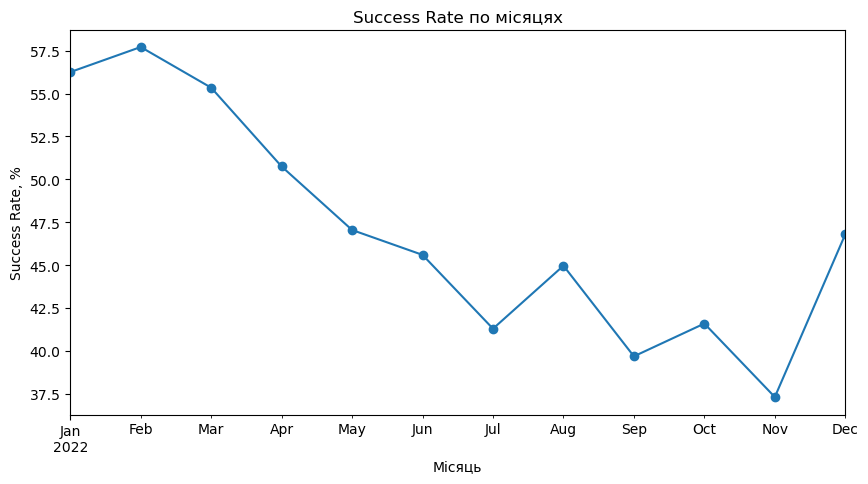

In [34]:
month_stats_plot = month_stats_tranzaktion.reset_index()

month_stats_plot.plot(
    x='month_per',
    y='success_rate',
    marker='o',
    figsize=(10, 5),
    legend=False)

plt.title('Success Rate по місяцях')
plt.xlabel('Місяць')
plt.ylabel('Success Rate, %')
plt.show()

**Висновок.** Протягом року спостерігалася загальна тенденція до зниження Payment Success Rate:

- **Лютий — 57,7%:** найвище значення.
- **Листопад — 37,3%:** найнижче значення.
- **Грудень — 46,8%:** часткове відновлення.

Попри грудневе покращення, успішність залишилася нижчою за рівень початку року. Далі розглянемо динаміку окремих типів платежів.

## 4. Initial та Recurrent

**Питання:** який тип платежів найбільше пов'язаний зі зниженням загального Success Rate?

Спочатку порівнюємо успішність `initial` і `reccurent` за рік.

In [36]:
payment = df.groupby(['payment_number','transaction_status']).size().reset_index().rename(columns = { 0 : 'cnt_tran'})
payment

,payment_number,transaction_status,cnt_tran
0,initial,fail,77774
1,initial,success,64476
2,reccurent,fail,236150
3,reccurent,success,186915


In [37]:
payment_succes = payment[payment['transaction_status'] == 'success']
payment_succes

,payment_number,transaction_status,cnt_tran
1,initial,success,64476
3,reccurent,success,186915


In [38]:
payment.groupby('payment_number')['cnt_tran'].sum()

payment_number
initial      142250
reccurent    423065
Name: cnt_tran, dtype: int64

In [39]:
success = payment_succes.set_index('payment_number')['cnt_tran']

total = payment.groupby('payment_number')['cnt_tran'].sum()

success_rate = (success / total * 100).round(2)

success_rate.reset_index()

,payment_number,cnt_tran
0,initial,45.33
1,reccurent,44.18


In [40]:
df.groupby('payment_number')['transaction_status'].value_counts(normalize = True).mul(100).reset_index(name = 'success_rate')

,payment_number,transaction_status,success_rate
0,initial,fail,54.674165
1,initial,success,45.325835
2,reccurent,fail,55.818846
3,reccurent,success,44.181154


In [41]:
payment_stats = pd.pivot_table(
    payment,
    index='payment_number',
    columns='transaction_status',
    values='cnt_tran')
payment_stats

transaction_status,fail,success
payment_number,,
initial,77774.0,64476.0
reccurent,236150.0,186915.0


In [42]:
payment_stats = payment_stats.rename_axis(columns=None)

payment_stats['total'] = payment_stats['fail'] + payment_stats['success']

payment_stats['success_rate'] = ((payment_stats['success'] / payment_stats['total']) * 100).round(2)

payment_stats[['success', 'total', 'success_rate']]

,success,total,success_rate
payment_number,,,
initial,64476.0,142250.0,45.33
reccurent,186915.0,423065.0,44.18


### Місячна динаміка Success Rate за типами платежу

Порівнюємо Success Rate для `initial` і `reccurent` у кожному місяці та будуємо графік.

In [43]:
success_rate_init_trial = (
    df.groupby(['month_per', 'payment_number'])
    ['transaction_status'].value_counts(normalize = True)
    .mul(100).reset_index(name = 'success_rate').round(2))

In [44]:
success_rate_init_trial = success_rate_init_trial[success_rate_init_trial['transaction_status'] == 'success']
success_rate_init_trial

,month_per,payment_number,transaction_status,success_rate
1,2022-01,initial,success,35.39
2,2022-01,reccurent,success,60.66
5,2022-02,initial,success,34.00
6,2022-02,reccurent,success,60.77
9,2022-03,initial,success,34.30
10,2022-03,reccurent,success,59.16
13,2022-04,initial,success,40.82
14,2022-04,reccurent,success,53.60
17,2022-05,initial,success,44.38
19,2022-05,reccurent,success,47.96


In [45]:
success_rate_plot = success_rate_init_trial.pivot(
    index='month_per',
    columns='payment_number',
    values='success_rate')
success_rate_plot

payment_number,initial,reccurent
month_per,,
2022-01,35.39,60.66
2022-02,34.00,60.77
2022-03,34.30,59.16
2022-04,40.82,53.60
2022-05,44.38,47.96
2022-06,45.64,45.58
2022-07,47.06,38.95
2022-08,45.22,44.91
2022-09,41.30,39.19


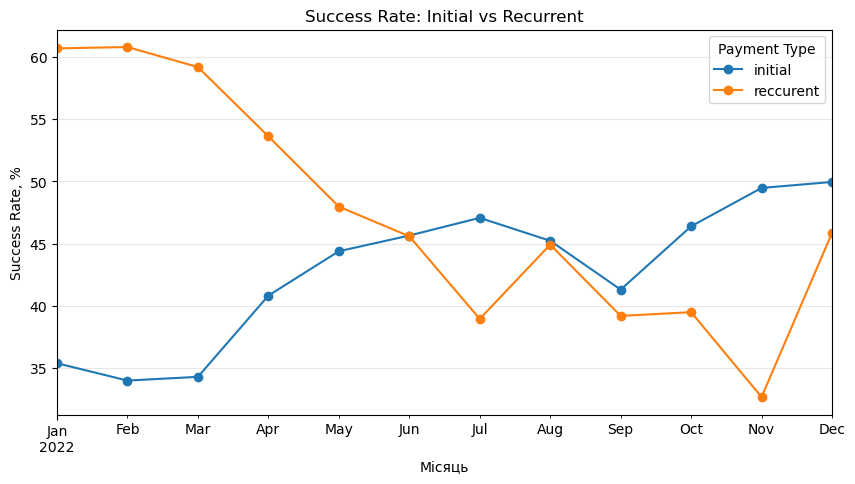

In [46]:
success_rate_plot.plot(
    marker='o',
    figsize=(10, 5))

plt.title('Success Rate: Initial vs Recurrent')
plt.xlabel('Місяць')
plt.ylabel('Success Rate, %')
plt.legend(title='Payment Type')
plt.grid(alpha=0.3)
plt.show()

**Висновок.** Типи платежів демонструють різну динаміку:

- **Initial:** SR загалом зростав — приблизно з **35%** на початку року до майже **50%** у грудні.
- **Recurrent:** SR знижувався з близько **61%** у січні–лютому до приблизно **33%** у листопаді, після чого частково відновився.

Зниження загального Payment Success Rate, ймовірно, значною мірою пов'язане з погіршенням проходження recurrent-платежів.

### Частка Initial та Recurrent у загальному обсязі

Розраховуємо частку кожного типу серед усіх платежів відповідного місяця.

In [47]:
payment_share = (
    df.groupby(['month_per', 'payment_number']).size().reset_index(name='cnt_tran'))

payment_share['total_month'] = (payment_share.groupby('month_per')['cnt_tran'].transform('sum'))

payment_share['share'] = (payment_share['cnt_tran'] /payment_share['total_month'] * 100).round(2)

payment_share

,month_per,payment_number,cnt_tran,total_month,share
0,2022-01,initial,4998,28664,17.44
1,2022-01,reccurent,23666,28664,82.56
2,2022-02,initial,2303,20150,11.43
3,2022-02,reccurent,17847,20150,88.57
4,2022-03,initial,2985,19449,15.35
5,2022-03,reccurent,16464,19449,84.65
6,2022-04,initial,5510,24757,22.26
7,2022-04,reccurent,19247,24757,77.74
8,2022-05,initial,8761,34336,25.52
9,2022-05,reccurent,25575,34336,74.48


In [48]:
payment_share_plot = payment_share.pivot(
    index='month_per',
    columns='payment_number',
    values='share')
payment_share_plot

payment_number,initial,reccurent
month_per,,
2022-01,17.44,82.56
2022-02,11.43,88.57
2022-03,15.35,84.65
2022-04,22.26,77.74
2022-05,25.52,74.48
2022-06,34.23,65.77
2022-07,28.97,71.03
2022-08,19.69,80.31
2022-09,23.65,76.35


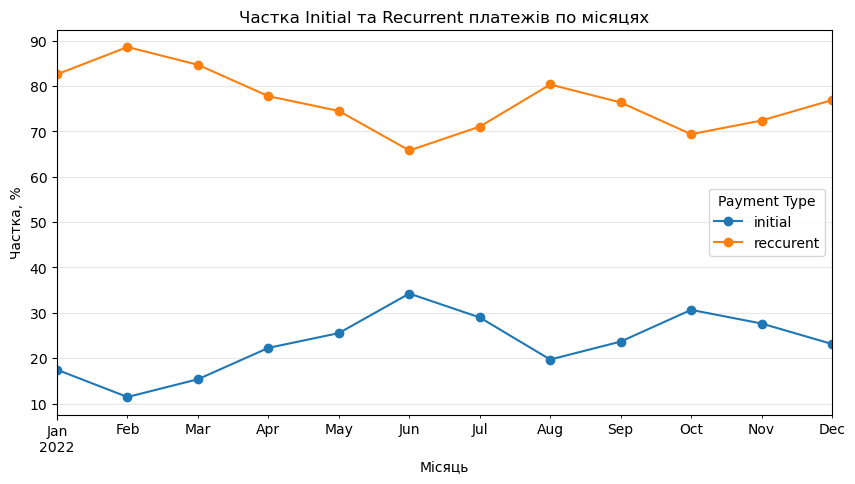

In [49]:
payment_share_plot.plot(
    marker='o',
    figsize=(10, 5))

plt.title('Частка Initial та Recurrent платежів по місяцях')
plt.xlabel('Місяць')
plt.ylabel('Частка, %')
plt.legend(title='Payment Type')
plt.grid(alpha=0.3)
plt.show()

**Висновок.** Recurrent-платежі формують основну частину потоку протягом року. Одночасно саме їхній SR суттєво знижувався, тому погіршення цього типу платежів є важливою частиною загальної проблеми.

## 5. Аналіз відмов Recurrent-платежів

**Що досліджуємо:** які коди помилок найчастіше трапляються серед невдалих recurrent-платежів.

In [50]:
df.head()

,order_id,event_time,user_id,price,payment_number,transaction_status,card_brand,card_type,bank_name,error_type,currency,card_country,month,month_per
0,c500aa10-30f8-4927-96c5-4e97b6afac83,2022-07-08 18:32:39,c1ed5188-caac-4d56-bad8-bc8ee0b09960,21.0,reccurent,fail,VISA,PREPAID,ADVANCED BANK OF ASIA LIMITED,3.08,USD,KHM,July,2022-07
1,624d6f30-c1bc-4778-a23e-6a227bac73ac,2022-06-09 22:18:36,c9ff65b8-75e6-467f-8715-21edb5fd06af,36.0,reccurent,fail,VISA,PREPAID,UNITED BANK FOR AFRICA GHANA LIMITED,3.02,USD,GHA,June,2022-06
2,4d75ca57-8883-49a9-b150-1ab7a47d12f8,2022-06-09 11:18:32,1005d4fb-1b7d-4715-835f-4d2a9bfe7cbb,36.0,initial,success,VISA,CREDIT,ICICI BANK LTD,NaN,USD,IND,June,2022-06
3,3fd11eed-4236-46aa-8f21-3c1e1a17a1bc,2022-06-29 13:50:47,866c4b2b-0285-43aa-98bd-d60bc3a78d7c,36.0,reccurent,fail,VISA,DEBIT,THE TORONTO-DOMINION BANK,3.02,USD,CAN,June,2022-06
4,3b19657f-1a34-4233-b25c-5d3b7fb32782,2022-06-17 15:16:47,bd2e4137-5526-4d9b-9dde-7482087fc321,9.0,reccurent,success,MASTERCARD,CREDIT,"CAPITAL ONE BANK (USA), NATIONAL ASSOCIATION",NaN,USD,USA,June,2022-06


In [51]:
#Частку кожного error_type серед усіх recurrent fail

df_rec_fail = df[(df['payment_number'] == 'reccurent') & (df['transaction_status'] == 'fail')]

rozpodil_erors = df_rec_fail['error_type'].value_counts(dropna=False).reset_index()

rozpodil_erors['rate_erors'] = ((rozpodil_erors['count'] / df_rec_fail.shape[0]) * 100).round(4)

rozpodil_erors

,error_type,count,rate_erors
0,3.02,121031,51.2517
1,3.10,27203,11.5194
2,3.08,16988,7.1937
3,3.01,12129,5.1361
4,3.04,11423,4.8372
5,4.05,11251,4.7643
6,4.03,8567,3.6278
7,2.08,6617,2.8020
8,0.01,4933,2.0889
9,4.02,2684,1.1366


**Висновок.** Найбільшу частку recurrent fail становлять:

- **`3.02` — близько 51,25%** усіх відмов.
- **`3.10` — близько 11,52%.**
- Далі — `3.08`, `3.01`, `3.04`, `4.05` та `4.03`.

Основна частина відмов припадає на невелику кількість кодів, тому далі розглядаємо **TOP-7 за місяцями**.

### Динаміка TOP-7 кодів серед recurrent fail

Відбираємо сім найчастіших кодів та розраховуємо їхню частку серед невдалих recurrent-платежів кожного місяця.

In [52]:
top7_errors = rozpodil_erors.head(7)['error_type']

month_errors = (df_rec_fail.groupby(['month_per', 'error_type'], dropna=False).size().reset_index(name='cnt_errors'))

month_errors['total_fail_month'] = (month_errors.groupby('month_per')['cnt_errors'].transform('sum'))

month_errors['rate_errors'] = (month_errors['cnt_errors'] / month_errors['total_fail_month'] * 100).round(2)
month_errors

,month_per,error_type,cnt_errors,total_fail_month,rate_errors
0,2022-01,0.01,73,9311,0.78
1,2022-01,0.02,5,9311,0.05
2,2022-01,0.03,19,9311,0.20
3,2022-01,2.01,8,9311,0.09
4,2022-01,2.06,18,9311,0.19
...,...,...,...,...,...
299,2022-12,5.02,4,19974,0.02
300,2022-12,5.08,115,19974,0.58
301,2022-12,6.01,12,19974,0.06
302,2022-12,7.01,76,19974,0.38


In [53]:
month_errors_top7 = month_errors[month_errors['error_type'].isin(top7_errors)].copy()
month_errors_top7

,month_per,error_type,cnt_errors,total_fail_month,rate_errors
8,2022-01,3.01,486,9311,5.22
9,2022-01,3.02,5286,9311,56.77
11,2022-01,3.04,493,9311,5.29
12,2022-01,3.08,771,9311,8.28
13,2022-01,3.10,664,9311,7.13
...,...,...,...,...,...
289,2022-12,3.04,638,19974,3.19
291,2022-12,3.08,2364,19974,11.84
292,2022-12,3.10,2615,19974,13.09
294,2022-12,4.03,193,19974,0.97


In [54]:
errors_plot = month_errors_top7.pivot(
    index='month_per',
    columns='error_type',
    values='rate_errors')

errors_plot

error_type,3.01,3.02,3.04,3.08,3.10,4.03,4.05
month_per,,,,,,,
2022-01,5.22,56.77,5.29,8.28,7.13,2.77,5.32
2022-02,7.47,53.43,7.75,4.66,9.20,5.43,0.19
2022-03,8.11,51.92,4.85,4.10,11.17,7.39,0.10
2022-04,7.64,56.39,4.32,3.78,10.32,7.05,0.12
2022-05,6.94,56.97,5.18,3.80,12.95,6.23,0.34
2022-06,5.32,52.07,6.88,6.29,9.44,7.05,0.13
2022-07,4.20,49.08,6.95,8.72,8.84,6.82,0.54
2022-08,4.62,53.79,6.73,8.10,10.58,4.11,0.23
2022-09,4.62,43.21,4.04,8.29,19.52,1.44,7.03


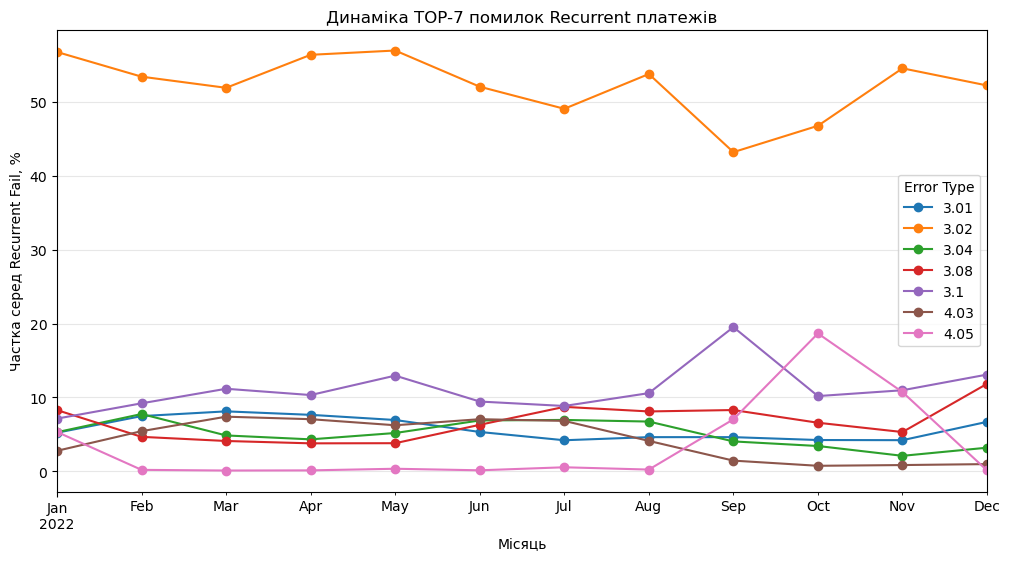

In [55]:
errors_plot.plot(
    marker='o',
    figsize=(12, 6))

plt.title('Динаміка TOP-7 помилок Recurrent платежів')
plt.xlabel('Місяць')
plt.ylabel('Частка серед Recurrent Fail, %')
plt.legend(title='Error Type')
plt.grid(alpha=0.3)
plt.show()

**Висновок.** Код `3.02` формує близько половини recurrent fail протягом року. Водночас його частка не зростає стабільно разом із падінням SR, тому погіршення не можна пояснити лише цим кодом.

В окремі місяці змінювалися й інші коди, зокрема **`3.10` у вересні** та **`4.05` у жовтні**.

## 6. Зв'язок між Recurrent Success Rate та структурою помилок

Зіставляємо місячний recurrent SR із частками TOP-7 кодів серед відмов.

In [56]:
success_rate_reccurent = success_rate_plot.reset_index()

success_rate_reccurent_table = success_rate_reccurent[['month_per','reccurent']].rename( columns = {'reccurent' : 'recurrent_success_rate'})

success_rate_reccurent_table = success_rate_reccurent_table.rename_axis(columns=None)

success_rate_reccurent_table

,month_per,recurrent_success_rate
0,2022-01,60.66
1,2022-02,60.77
2,2022-03,59.16
3,2022-04,53.60
4,2022-05,47.96
5,2022-06,45.58
6,2022-07,38.95
7,2022-08,44.91
8,2022-09,39.19
9,2022-10,39.49


In [57]:
month_errors_top7_table = errors_plot.reset_index()

month_errors_top7_table = month_errors_top7_table.rename_axis(columns=None)

month_errors_top7_table

,month_per,3.01,3.02,3.04,3.08,3.1,4.03,4.05
0,2022-01,5.22,56.77,5.29,8.28,7.13,2.77,5.32
1,2022-02,7.47,53.43,7.75,4.66,9.20,5.43,0.19
2,2022-03,8.11,51.92,4.85,4.10,11.17,7.39,0.10
3,2022-04,7.64,56.39,4.32,3.78,10.32,7.05,0.12
4,2022-05,6.94,56.97,5.18,3.80,12.95,6.23,0.34
5,2022-06,5.32,52.07,6.88,6.29,9.44,7.05,0.13
6,2022-07,4.20,49.08,6.95,8.72,8.84,6.82,0.54
7,2022-08,4.62,53.79,6.73,8.10,10.58,4.11,0.23
8,2022-09,4.62,43.21,4.04,8.29,19.52,1.44,7.03
9,2022-10,4.23,46.78,3.42,6.57,10.18,0.74,18.66


In [58]:
recurrent_success_rate_stryk = month_errors_top7_table.merge(
    success_rate_reccurent_table,
    on='month_per',
    how='left')
recurrent_success_rate_stryk

,month_per,3.01,3.02,3.04,3.08,3.1,4.03,4.05,recurrent_success_rate
0,2022-01,5.22,56.77,5.29,8.28,7.13,2.77,5.32,60.66
1,2022-02,7.47,53.43,7.75,4.66,9.20,5.43,0.19,60.77
2,2022-03,8.11,51.92,4.85,4.10,11.17,7.39,0.10,59.16
3,2022-04,7.64,56.39,4.32,3.78,10.32,7.05,0.12,53.60
4,2022-05,6.94,56.97,5.18,3.80,12.95,6.23,0.34,47.96
5,2022-06,5.32,52.07,6.88,6.29,9.44,7.05,0.13,45.58
6,2022-07,4.20,49.08,6.95,8.72,8.84,6.82,0.54,38.95
7,2022-08,4.62,53.79,6.73,8.10,10.58,4.11,0.23,44.91
8,2022-09,4.62,43.21,4.04,8.29,19.52,1.44,7.03,39.19
9,2022-10,4.23,46.78,3.42,6.57,10.18,0.74,18.66,39.49


**Висновок.** Структура помилок змінювалася нерівномірно. Не виявлено одного коду, частка якого стабільно зростала разом із падінням SR.

У вересні виділявся `3.10`, у жовтні — `4.05`, а в листопаді разом із мінімальним SR знову зросла частка `3.02`.

### Зміни місяць до місяця: частки серед відмов

Розраховуємо місячну зміну recurrent SR і частки кожного коду з TOP-7. Потім розглядаємо місяці зниження SR.

**Питання:** на скільки процентних пунктів змінився SR і частка якого коду в цей час зросла найбільше?

In [59]:
recurrent_success_rate_stryk['success_rate_mom'] = recurrent_success_rate_stryk['recurrent_success_rate'].diff()

recurrent_success_rate_stryk['3.01_mom'] = recurrent_success_rate_stryk[3.01].diff()

recurrent_success_rate_stryk['3.02_mom'] = recurrent_success_rate_stryk[3.02].diff()

recurrent_success_rate_stryk['3.04_mom'] = recurrent_success_rate_stryk[3.04].diff()

recurrent_success_rate_stryk['3.08_mom'] = recurrent_success_rate_stryk[3.08].diff()

recurrent_success_rate_stryk['3.1_mom'] = recurrent_success_rate_stryk[3.1].diff()

recurrent_success_rate_stryk['4.03_mom'] = recurrent_success_rate_stryk[4.03].diff()

recurrent_success_rate_stryk['4.05_mom'] = recurrent_success_rate_stryk[4.05].diff()

recurrent_success_rate_stryk

,month_per,3.01,3.02,3.04,3.08,3.1,4.03,4.05,recurrent_success_rate,success_rate_mom,3.01_mom,3.02_mom,3.04_mom,3.08_mom,3.1_mom,4.03_mom,4.05_mom
0,2022-01,5.22,56.77,5.29,8.28,7.13,2.77,5.32,60.66,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2022-02,7.47,53.43,7.75,4.66,9.20,5.43,0.19,60.77,0.11,2.25,-3.34,2.46,-3.62,2.07,2.66,-5.13
2,2022-03,8.11,51.92,4.85,4.10,11.17,7.39,0.10,59.16,-1.61,0.64,-1.51,-2.90,-0.56,1.97,1.96,-0.09
3,2022-04,7.64,56.39,4.32,3.78,10.32,7.05,0.12,53.60,-5.56,-0.47,4.47,-0.53,-0.32,-0.85,-0.34,0.02
4,2022-05,6.94,56.97,5.18,3.80,12.95,6.23,0.34,47.96,-5.64,-0.70,0.58,0.86,0.02,2.63,-0.82,0.22
5,2022-06,5.32,52.07,6.88,6.29,9.44,7.05,0.13,45.58,-2.38,-1.62,-4.90,1.70,2.49,-3.51,0.82,-0.21
6,2022-07,4.20,49.08,6.95,8.72,8.84,6.82,0.54,38.95,-6.63,-1.12,-2.99,0.07,2.43,-0.60,-0.23,0.41
7,2022-08,4.62,53.79,6.73,8.10,10.58,4.11,0.23,44.91,5.96,0.42,4.71,-0.22,-0.62,1.74,-2.71,-0.31
8,2022-09,4.62,43.21,4.04,8.29,19.52,1.44,7.03,39.19,-5.72,0.00,-10.58,-2.69,0.19,8.94,-2.67,6.80
9,2022-10,4.23,46.78,3.42,6.57,10.18,0.74,18.66,39.49,0.30,-0.39,3.57,-0.62,-1.72,-9.34,-0.70,11.63


In [60]:
recurrent_success_rate_stryk_filter = recurrent_success_rate_stryk[recurrent_success_rate_stryk['success_rate_mom'] < 0]
recurrent_success_rate_stryk_filter

,month_per,3.01,3.02,3.04,3.08,3.1,4.03,4.05,recurrent_success_rate,success_rate_mom,3.01_mom,3.02_mom,3.04_mom,3.08_mom,3.1_mom,4.03_mom,4.05_mom
2,2022-03,8.11,51.92,4.85,4.10,11.17,7.39,0.10,59.16,-1.61,0.64,-1.51,-2.90,-0.56,1.97,1.96,-0.09
3,2022-04,7.64,56.39,4.32,3.78,10.32,7.05,0.12,53.60,-5.56,-0.47,4.47,-0.53,-0.32,-0.85,-0.34,0.02
4,2022-05,6.94,56.97,5.18,3.80,12.95,6.23,0.34,47.96,-5.64,-0.70,0.58,0.86,0.02,2.63,-0.82,0.22
5,2022-06,5.32,52.07,6.88,6.29,9.44,7.05,0.13,45.58,-2.38,-1.62,-4.90,1.70,2.49,-3.51,0.82,-0.21
6,2022-07,4.20,49.08,6.95,8.72,8.84,6.82,0.54,38.95,-6.63,-1.12,-2.99,0.07,2.43,-0.60,-0.23,0.41
8,2022-09,4.62,43.21,4.04,8.29,19.52,1.44,7.03,39.19,-5.72,0.00,-10.58,-2.69,0.19,8.94,-2.67,6.80
10,2022-11,4.21,54.56,2.09,5.31,10.97,0.84,10.72,32.68,-6.81,-0.02,7.78,-1.33,-1.26,0.79,0.10,-7.94


In [61]:
#частка конкретної помилки серед усіх recurrent fail
#«Яка структура причин серед невдалих платежів?»
recurrent_success_rate_stryk_filter[['month_per', 'success_rate_mom', '3.01_mom', '3.02_mom','3.04_mom', '3.08_mom', '3.1_mom', '4.03_mom', '4.05_mom']]

,month_per,success_rate_mom,3.01_mom,3.02_mom,3.04_mom,3.08_mom,3.1_mom,4.03_mom,4.05_mom
2,2022-03,-1.61,0.64,-1.51,-2.90,-0.56,1.97,1.96,-0.09
3,2022-04,-5.56,-0.47,4.47,-0.53,-0.32,-0.85,-0.34,0.02
4,2022-05,-5.64,-0.70,0.58,0.86,0.02,2.63,-0.82,0.22
5,2022-06,-2.38,-1.62,-4.90,1.70,2.49,-3.51,0.82,-0.21
6,2022-07,-6.63,-1.12,-2.99,0.07,2.43,-0.60,-0.23,0.41
8,2022-09,-5.72,0.00,-10.58,-2.69,0.19,8.94,-2.67,6.80
10,2022-11,-6.81,-0.02,7.78,-1.33,-1.26,0.79,0.10,-7.94


**Висновок.** MoM-порівняння підтверджує, що в різні місяці найбільше зростали різні коди. На цьому етапі падіння SR не можна пояснити лише однією помилкою.

### Частота помилок серед усіх recurrent-платежів

Тепер оцінюємо частоту кодів відносно **всіх recurrent-платежів**, а не лише невдалих операцій.

In [62]:
# Наскільки часто кожна причина валить усі recurrent-платежі?

In [63]:
month_errors_all_stats = (df_rec_fail.groupby(['month_per', 'error_type'], dropna=False).size().reset_index(name='cnt_errors'))

total_reccurent_month = (df[df['payment_number'] == 'reccurent'].groupby('month_per').size().reset_index(name='total_reccurent'))

monthly_recurrent_error_stats = month_errors_all_stats.merge(
    total_reccurent_month,
    on = 'month_per',
    how = 'left')
monthly_recurrent_error_stats

,month_per,error_type,cnt_errors,total_reccurent
0,2022-01,0.01,73,23666
1,2022-01,0.02,5,23666
2,2022-01,0.03,19,23666
3,2022-01,2.01,8,23666
4,2022-01,2.06,18,23666
...,...,...,...,...
299,2022-12,5.02,4,36888
300,2022-12,5.08,115,36888
301,2022-12,6.01,12,36888
302,2022-12,7.01,76,36888


**Що зроблено.** Для кожного місяця пораховано кількість відмов із кожним кодом і загальну кількість recurrent-платежів. Таблиці об'єднано за `month_per`.

Знаменник для подальшого Error Rate — **усі recurrent-платежі відповідного місяця**.

**Розрахунок Error Rate.** Ділимо кількість відмов із конкретним кодом на всі recurrent-платежі відповідного місяця. Для TOP-7 кодів формуємо таблицю та графік.

In [64]:
monthly_recurrent_error_stats['error_rate'] = ((monthly_recurrent_error_stats['cnt_errors'] /
                                                monthly_recurrent_error_stats['total_reccurent']) * 100).round(2)

monthly_recurrent_error_stats_top7 = monthly_recurrent_error_stats[monthly_recurrent_error_stats['error_type'].isin(top7_errors)].copy()

monthly_recurrent_error_stats_top7 

,month_per,error_type,cnt_errors,total_reccurent,error_rate
8,2022-01,3.01,486,23666,2.05
9,2022-01,3.02,5286,23666,22.34
11,2022-01,3.04,493,23666,2.08
12,2022-01,3.08,771,23666,3.26
13,2022-01,3.10,664,23666,2.81
...,...,...,...,...,...
289,2022-12,3.04,638,36888,1.73
291,2022-12,3.08,2364,36888,6.41
292,2022-12,3.10,2615,36888,7.09
294,2022-12,4.03,193,36888,0.52


In [65]:
errors_plot_all = monthly_recurrent_error_stats_top7 .pivot(
    index='month_per',
    columns='error_type',
    values='error_rate')

errors_plot_all

error_type,3.01,3.02,3.04,3.08,3.10,4.03,4.05
month_per,,,,,,,
2022-01,2.05,22.34,2.08,3.26,2.81,1.09,2.09
2022-02,2.93,20.96,3.04,1.83,3.61,2.13,0.07
2022-03,3.31,21.20,1.98,1.68,4.56,3.02,0.04
2022-04,3.54,26.17,2.01,1.76,4.79,3.27,0.06
2022-05,3.61,29.64,2.70,1.98,6.74,3.24,0.18
2022-06,2.90,28.34,3.74,3.42,5.14,3.84,0.07
2022-07,2.56,29.97,4.24,5.33,5.40,4.17,0.33
2022-08,2.55,29.63,3.71,4.46,5.83,2.26,0.13
2022-09,2.81,26.28,2.46,5.04,11.87,0.88,4.28


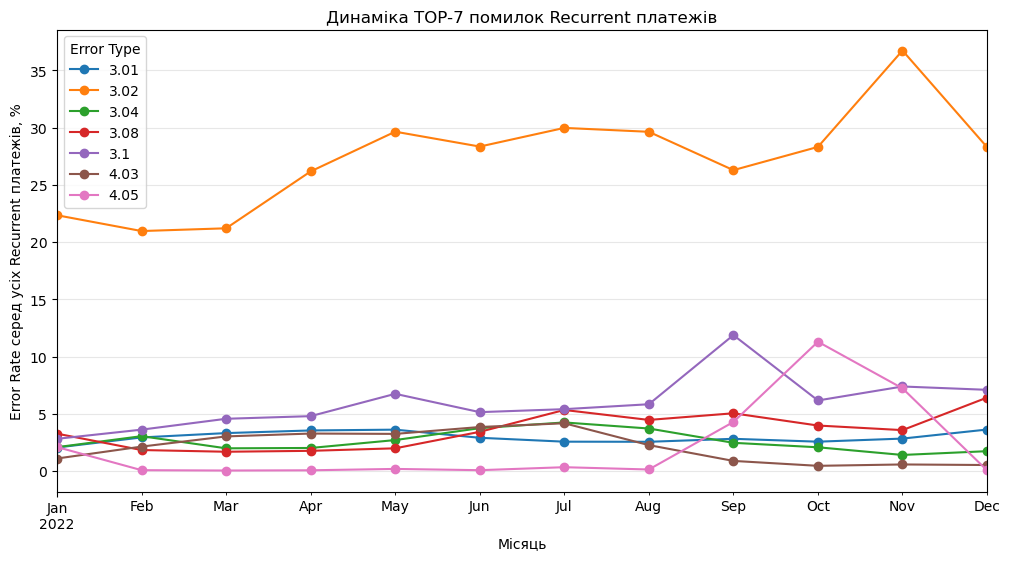

In [66]:
errors_plot_all.plot(
    marker='o',
    figsize=(12, 6))

plt.title('Динаміка TOP-7 помилок Recurrent платежів')
plt.xlabel('Місяць')
plt.ylabel('Error Rate серед усіх Recurrent платежів, %')
plt.legend(title='Error Type')
plt.grid(alpha=0.3)
plt.show()

**Зіставлення зі змінами Success Rate.** Об'єднуємо частоти помилок із recurrent SR, обчислюємо місячні зміни та залишаємо місяці його зниження.

In [67]:
success_rate_reccurent_table

,month_per,recurrent_success_rate
0,2022-01,60.66
1,2022-02,60.77
2,2022-03,59.16
3,2022-04,53.60
4,2022-05,47.96
5,2022-06,45.58
6,2022-07,38.95
7,2022-08,44.91
8,2022-09,39.19
9,2022-10,39.49


In [68]:
monthly_recurrent_error_stats_top7_table = errors_plot_all.reset_index()

monthly_recurrent_error_stats_top7_table = monthly_recurrent_error_stats_top7_table.rename_axis(columns=None) 

In [69]:
all_stats_rec_eror = monthly_recurrent_error_stats_top7_table.merge(
    success_rate_reccurent_table,
    on = 'month_per',
    how = 'left') 

all_stats_rec_eror

,month_per,3.01,3.02,3.04,3.08,3.1,4.03,4.05,recurrent_success_rate
0,2022-01,2.05,22.34,2.08,3.26,2.81,1.09,2.09,60.66
1,2022-02,2.93,20.96,3.04,1.83,3.61,2.13,0.07,60.77
2,2022-03,3.31,21.20,1.98,1.68,4.56,3.02,0.04,59.16
3,2022-04,3.54,26.17,2.01,1.76,4.79,3.27,0.06,53.60
4,2022-05,3.61,29.64,2.70,1.98,6.74,3.24,0.18,47.96
5,2022-06,2.90,28.34,3.74,3.42,5.14,3.84,0.07,45.58
6,2022-07,2.56,29.97,4.24,5.33,5.40,4.17,0.33,38.95
7,2022-08,2.55,29.63,3.71,4.46,5.83,2.26,0.13,44.91
8,2022-09,2.81,26.28,2.46,5.04,11.87,0.88,4.28,39.19
9,2022-10,2.56,28.31,2.07,3.97,6.16,0.45,11.29,39.49


In [70]:
all_stats_rec_eror['success_rate_mom'] = all_stats_rec_eror['recurrent_success_rate'].diff()
all_stats_rec_eror['3.01_mom'] = all_stats_rec_eror[3.01].diff()
all_stats_rec_eror['3.02_mom'] = all_stats_rec_eror[3.02].diff()
all_stats_rec_eror['3.04_mom'] = all_stats_rec_eror[3.04].diff()
all_stats_rec_eror['3.08_mom'] = all_stats_rec_eror[3.08].diff()
all_stats_rec_eror['3.1_mom'] = all_stats_rec_eror[3.1].diff()
all_stats_rec_eror['4.03_mom'] = all_stats_rec_eror[4.03].diff()
all_stats_rec_eror['4.05_mom'] = all_stats_rec_eror[4.05].diff()

all_stats_rec_eror

,month_per,3.01,3.02,3.04,3.08,3.1,4.03,4.05,recurrent_success_rate,success_rate_mom,3.01_mom,3.02_mom,3.04_mom,3.08_mom,3.1_mom,4.03_mom,4.05_mom
0,2022-01,2.05,22.34,2.08,3.26,2.81,1.09,2.09,60.66,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2022-02,2.93,20.96,3.04,1.83,3.61,2.13,0.07,60.77,0.11,0.88,-1.38,0.96,-1.43,0.80,1.04,-2.02
2,2022-03,3.31,21.20,1.98,1.68,4.56,3.02,0.04,59.16,-1.61,0.38,0.24,-1.06,-0.15,0.95,0.89,-0.03
3,2022-04,3.54,26.17,2.01,1.76,4.79,3.27,0.06,53.60,-5.56,0.23,4.97,0.03,0.08,0.23,0.25,0.02
4,2022-05,3.61,29.64,2.70,1.98,6.74,3.24,0.18,47.96,-5.64,0.07,3.47,0.69,0.22,1.95,-0.03,0.12
5,2022-06,2.90,28.34,3.74,3.42,5.14,3.84,0.07,45.58,-2.38,-0.71,-1.30,1.04,1.44,-1.60,0.60,-0.11
6,2022-07,2.56,29.97,4.24,5.33,5.40,4.17,0.33,38.95,-6.63,-0.34,1.63,0.50,1.91,0.26,0.33,0.26
7,2022-08,2.55,29.63,3.71,4.46,5.83,2.26,0.13,44.91,5.96,-0.01,-0.34,-0.53,-0.87,0.43,-1.91,-0.20
8,2022-09,2.81,26.28,2.46,5.04,11.87,0.88,4.28,39.19,-5.72,0.26,-3.35,-1.25,0.58,6.04,-1.38,4.15
9,2022-10,2.56,28.31,2.07,3.97,6.16,0.45,11.29,39.49,0.30,-0.25,2.03,-0.39,-1.07,-5.71,-0.43,7.01


In [71]:
all_stats_rec_eror_filter = all_stats_rec_eror[all_stats_rec_eror['success_rate_mom'] < 0].copy()
all_stats_rec_eror_filter

,month_per,3.01,3.02,3.04,3.08,3.1,4.03,4.05,recurrent_success_rate,success_rate_mom,3.01_mom,3.02_mom,3.04_mom,3.08_mom,3.1_mom,4.03_mom,4.05_mom
2,2022-03,3.31,21.20,1.98,1.68,4.56,3.02,0.04,59.16,-1.61,0.38,0.24,-1.06,-0.15,0.95,0.89,-0.03
3,2022-04,3.54,26.17,2.01,1.76,4.79,3.27,0.06,53.60,-5.56,0.23,4.97,0.03,0.08,0.23,0.25,0.02
4,2022-05,3.61,29.64,2.70,1.98,6.74,3.24,0.18,47.96,-5.64,0.07,3.47,0.69,0.22,1.95,-0.03,0.12
5,2022-06,2.90,28.34,3.74,3.42,5.14,3.84,0.07,45.58,-2.38,-0.71,-1.30,1.04,1.44,-1.60,0.60,-0.11
6,2022-07,2.56,29.97,4.24,5.33,5.40,4.17,0.33,38.95,-6.63,-0.34,1.63,0.50,1.91,0.26,0.33,0.26
8,2022-09,2.81,26.28,2.46,5.04,11.87,0.88,4.28,39.19,-5.72,0.26,-3.35,-1.25,0.58,6.04,-1.38,4.15
10,2022-11,2.83,36.73,1.40,3.57,7.38,0.57,7.22,32.68,-6.81,0.27,8.42,-0.67,-0.40,1.22,0.12,-4.07


**Найбільше зростання серед TOP-7.** Для кожного місяця падіння SR визначаємо код із найбільшим приростом Error Rate.

In [72]:
error_mom_cols = [
    '3.01_mom',
    '3.02_mom',
    '3.04_mom',
    '3.08_mom',
    '3.1_mom',
    '4.03_mom',
    '4.05_mom']

all_stats_rec_eror_filter['biggest_error_growth'] = (all_stats_rec_eror_filter[error_mom_cols].idxmax(axis=1))

all_stats_rec_eror_filter['biggest_growth_value'] = (all_stats_rec_eror_filter[error_mom_cols].max(axis=1))

all_stats_rec_eror_filter[['month_per','success_rate_mom','biggest_error_growth','biggest_growth_value']]

,month_per,success_rate_mom,biggest_error_growth,biggest_growth_value
2,2022-03,-1.61,3.1_mom,0.95
3,2022-04,-5.56,3.02_mom,4.97
4,2022-05,-5.64,3.02_mom,3.47
5,2022-06,-2.38,3.08_mom,1.44
6,2022-07,-6.63,3.08_mom,1.91
8,2022-09,-5.72,3.1_mom,6.04
10,2022-11,-6.81,3.02_mom,8.42


**Висновок.** Серед досліджуваних TOP-7 кодів найбільші прирости Error Rate у проблемні місяці мали:

- **`3.02` — у квітні, травні та листопаді.**
- **`3.10` — у вересні.**
- **`3.08` — у червні–липні.**

Погіршення recurrent SR супроводжувалося змінами різних кодів у різні періоди року.

## 7. Аналіз помилки 3.02 за банками

**Питання:** чи концентрується `3.02` в окремих банках-емітентах?

Спочатку визначаємо банки з найбільшою кількістю `3.02`, потім зіставляємо її з обсягом recurrent-платежів, щоб оцінити Error Rate.

In [73]:
#Частка кожного error_type серед усіх recurrent fail

df_rec_fail = df[(df['payment_number'] == 'reccurent') & (df['transaction_status'] == 'fail')]

df_rec_fail_3_02 = df_rec_fail[df_rec_fail['error_type'] == 3.02].groupby('bank_name').size().reset_index(name = 'cnt_pom')

df_rec_fail_3_02.sort_values (by = 'cnt_pom', ascending = False).head(20)

,bank_name,cnt_pom
1666,SUTTON BANK,6360
1700,THE BANCORP BANK,5248
576,COMMONWEALTH BANK OF AUSTRALIA,4375
319,"BANK OF AMERICA, NATIONAL ASSOCIATION",3325
1655,"STRIDE BANK, NATIONAL ASSOCIATION",3225
1190,METABANK,2022
1490,REVOLUT LIMITED,2008
479,"CAPITAL ONE BANK (USA), NATIONAL ASSOCIATION",1897
288,"BANCORP BANK, THE",1893
1491,REVOLUT LTD,1847


**Обсяг платежів та Error Rate.** Для банків рахуємо загальну кількість recurrent-платежів, кількість `3.02` та частку цього коду.

In [74]:
bank_302_stats = (df[df['payment_number'] == 'reccurent'].groupby('bank_name').agg(
        total_recurrent = ('order_id', 'size'),
        cnt_302 = ('error_type', lambda x: (x == 3.02).sum())).reset_index())

bank_302_stats['error_rate_302'] = (bank_302_stats['cnt_302'] / bank_302_stats['total_recurrent'] * 100).round(2)

bank_302_stats.sort_values(by = 'error_rate_302', ascending = False).head(20)

,bank_name,total_recurrent,cnt_302,error_rate_302
1158,EGYPTIAN BANKS CO. FOR TECHNOLOGICAL ADVANCEME...,5,5,100.0
1265,FIRST ARKANSAS BANK & TRUST,2,2,100.0
457,BANISTMO S.A. - NEQUI,24,24,100.0
452,BANESCO BANCO MULTIPLE S.A.,5,5,100.0
1256,FINECOBANK SPA,1,1,100.0
2542,SOCIAL BANK SA,5,5,100.0
1807,"LIFECARD CO., LTD.",7,7,100.0
1910,MERCHANTRADE ASIA SDN. BHD.,5,5,100.0
69,AFRICAN BANKING CORPORATION (MOCAMBIQUE) SARL,5,5,100.0
2449,SANGER BANK,6,6,100.0


### Відбір банків за річним обсягом

До подальшого порівняння включаємо банки з **не менше ніж 500 recurrent-платежів за рік**, щоб відсіяти малий річний обсяг.

In [75]:
bank_302_stats_500 = bank_302_stats[bank_302_stats['total_recurrent'] >= 500]

bank_302_stats_500.sort_values(by = 'error_rate_302', ascending = False).head(20)

,bank_name,total_recurrent,cnt_302,error_rate_302
2172,"PAYMAYA PHILIPPINES, INC.",500,419,83.80
831,CHOICE FINANCIAL GROUP,1427,1077,75.47
324,BANCO DE CREDITO E INVERSIONES,948,708,74.68
314,"BANCO DAVIVIENDA, S.A.",501,370,73.85
448,"BANCORP BANK, THE",2897,1893,65.34
2196,PEOPLES TRUST COMPANY,2140,1353,63.22
1971,"MVB BANK, INC",1532,967,63.12
1919,METABANK,3244,2022,62.33
1753,KOHO FINANCIAL INCORPORATED,701,428,61.06
445,BANCOLOMBIA S.A.- NEQUI,561,332,59.18


In [76]:
bank_302_stats_500.sort_values(by = 'cnt_302', ascending = False).head(20)

,bank_name,total_recurrent,cnt_302,error_rate_302
2673,SUTTON BANK,14278,6360,44.54
2730,THE BANCORP BANK,10185,5248,51.53
915,COMMONWEALTH BANK OF AUSTRALIA,10620,4375,41.20
497,"BANK OF AMERICA, NATIONAL ASSOCIATION",12687,3325,26.21
2654,"STRIDE BANK, NATIONAL ASSOCIATION",6374,3225,50.60
1919,METABANK,3244,2022,62.33
2396,REVOLUT LIMITED,4008,2008,50.10
755,"CAPITAL ONE BANK (USA), NATIONAL ASSOCIATION",5751,1897,32.99
448,"BANCORP BANK, THE",2897,1893,65.34
2397,REVOLUT LTD,3599,1847,51.32


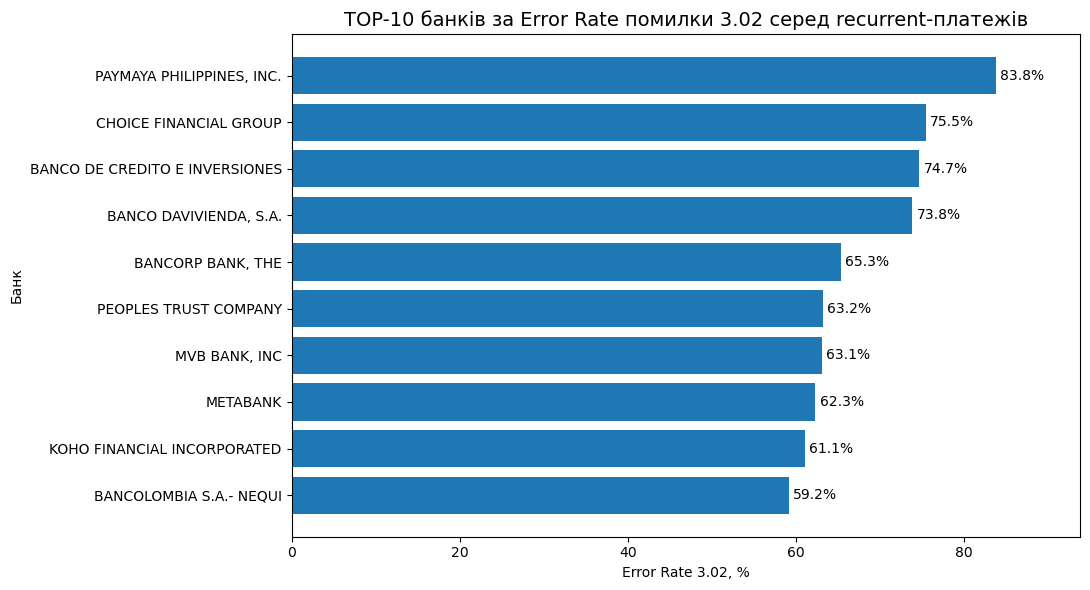

In [77]:
top10_banks_302 = (bank_302_stats_500.sort_values(by='error_rate_302', ascending=False).head(10).sort_values(by='error_rate_302'))

plt.figure(figsize=(11, 6))

bars = plt.barh(
    top10_banks_302['bank_name'],
    top10_banks_302['error_rate_302'])

plt.title('TOP-10 банків за Error Rate помилки 3.02 серед recurrent-платежів', fontsize=14)
plt.xlabel('Error Rate 3.02, %')
plt.ylabel('Банк')

for bar in bars:
    width = bar.get_width()
    
    plt.text(
        width + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f'{width:.1f}%',
        va='center')

plt.xlim(0, top10_banks_302['error_rate_302'].max() + 10)

plt.tight_layout()
plt.show()

**Висновок.** Серед відібраних банків найвищий Error Rate `3.02` спостерігається у:

- **PAYMAYA PHILIPPINES — 83,8%.**
- **CHOICE FINANCIAL GROUP — 75,5%.**
- **BANCO DE CREDITO E INVERSIONES — 74,7%.**
- **BANCO DAVIVIENDA, S.A. — 73,8%.**

Найбільша кількість помилок не завжди означає найвищу частоту. Наприклад, **SUTTON BANK має 6 360 помилок при Error Rate 44,5%**.

Для визначення масштабу проблеми потрібно одночасно враховувати **кількість відмов та їхню частку**. Далі розглянемо ці показники за місяцями.

### Місячна динаміка 3.02 за банками

Для кожного банку та місяця визначаємо:

- загальну кількість recurrent-платежів;
- кількість помилок `3.02`;
- Error Rate `3.02`.

Мета — визначити банки з найбільшими змінами в проблемні місяці, насамперед у листопаді.

In [78]:
bank_302_stats_month = (df[df['payment_number'] == 'reccurent'].groupby(['month_per','bank_name']).agg(
        total_recurrent = ('order_id', 'size'),
        cnt_302 = ('error_type', lambda x: (x == 3.02).sum())).reset_index())

bank_302_stats_month['error_rate_302'] = (bank_302_stats_month['cnt_302'] / bank_302_stats_month['total_recurrent'] * 100).round(2)

bank_302_stats_month

,month_per,bank_name,total_recurrent,cnt_302,error_rate_302
0,2022-01,1ST ADVANTAGE FEDERAL CREDIT UNION,1,0,0.00
1,2022-01,1ST COMMUNITY CREDIT UNION,4,0,0.00
2,2022-01,1ST FINANCIAL BANK USA,1,0,0.00
3,2022-01,"365.BANK, A. S.",7,2,28.57
4,2022-01,4FRONT CREDIT UNION,4,0,0.00
...,...,...,...,...,...
17668,2022-12,ZYNC CARD,1,0,0.00
17669,2022-12,Zipmoney Payments Pty Ltd,2,0,0.00
17670,2022-12,mBank S.A.,1,0,0.00
17671,2022-12,permanent tsb plc,3,0,0.00


**Відбір банків.** Залишаємо місячні показники для банків, які пройшли річний поріг обсягу платежів.

In [79]:
banks_500 = bank_302_stats_500['bank_name']

In [80]:
bank_302_stats_month_500 = bank_302_stats_month[bank_302_stats_month['bank_name'].isin(banks_500)].copy()

In [81]:
bank_302_stats_month_500

,month_per,bank_name,total_recurrent,cnt_302,error_rate_302
12,2022-01,ABSA BANK LIMITED,42,9,21.43
14,2022-01,ABU DHABI COMMERCIAL BANK,44,0,0.00
58,2022-01,AMERICAN EXPRESS COMPANY,4,0,0.00
64,2022-01,ANZ BANK NEW ZEALAND LIMITED,82,18,21.95
81,2022-01,ASB BANK,95,28,29.47
...,...,...,...,...,...
17628,2022-12,"WELLS FARGO BANK, NATIONAL ASSOCIATION",1058,142,13.42
17633,2022-12,WESTPAC BANKING CORPORATION,296,128,43.24
17634,2022-12,WESTPAC NEW ZEALAND LIMITED,108,38,35.19
17645,2022-12,WOODFOREST NATIONAL BANK,41,15,36.59


### Жовтень–листопад–грудень: зміни Error Rate

Для відібраних банків порівнюємо місячну частоту `3.02`. Досліджуємо листопадне зростання загального recurrent Error Rate цього коду на **8,42 п.п.** та подальшу грудневу динаміку.

In [82]:
month_bank_stats = bank_302_stats_month_500[(bank_302_stats_month_500['month_per'] == '2022-10') | 
(bank_302_stats_month_500['month_per'] == '2022-11') | 
(bank_302_stats_month_500['month_per'] == '2022-12')].copy()

In [83]:
month_bank_stats_table = pd.pivot_table(
    month_bank_stats ,
    index='bank_name',
    columns='month_per',
    values='error_rate_302')

month_bank_stats_table

month_per,2022-10,2022-11,2022-12
bank_name,,,
ABSA BANK LIMITED,30.36,11.11,39.13
ABU DHABI COMMERCIAL BANK,15.09,5.41,2.27
AMERICAN EXPRESS COMPANY,0.48,0.00,1.52
ANZ BANK NEW ZEALAND LIMITED,32.41,34.57,32.32
ASB BANK,38.29,29.61,35.83
...,...,...,...
"WELLS FARGO BANK, NATIONAL ASSOCIATION",10.79,16.28,13.42
WESTPAC BANKING CORPORATION,50.77,41.90,43.24
WESTPAC NEW ZEALAND LIMITED,41.59,49.04,35.19


In [84]:
month_bank_stats_table.columns = month_bank_stats_table.columns.astype(str)

month_bank_stats_table['nov_mom'] = month_bank_stats_table['2022-11'] - month_bank_stats_table['2022-10']

month_bank_stats_table['dec_mom'] = month_bank_stats_table['2022-12'] - month_bank_stats_table['2022-11']

month_bank_stats_table.sort_values(by = 'nov_mom',ascending = False).head(20)

month_per,2022-10,2022-11,2022-12,nov_mom,dec_mom
bank_name,,,,,
BANCOPPEL S.A. INSTITUCION DE BANCA MULTIPLE,10.53,52.33,60.45,41.80,8.12
"JOINT-STOCK COMPANY ""BANK OF GEORGIA""",18.60,54.17,36.59,35.57,-17.58
"PAYMAYA PHILIPPINES, INC.",57.14,92.68,30.00,35.54,-62.68
GUARANTY TRUST BANK PLC,19.44,52.38,24.00,32.94,-28.38
COASTAL COMMUNITY BANK,47.37,77.78,16.67,30.41,-61.11
MONZO BANK LIMITED,30.11,58.75,50.00,28.64,-8.75
BANK OF THE PHILIPPINE ISLANDS,13.21,40.00,8.33,26.79,-31.67
NATIONWIDE BUILDING SOCIETY,2.00,28.77,38.03,26.77,9.26
"BANCO NACIONAL DE MEXICO, S.A.",18.49,44.79,38.66,26.30,-6.13


**Як читати показники:**

- `nov_mom` — зміна Error Rate `3.02` у листопаді відносно жовтня.
- `dec_mom` — зміна Error Rate `3.02` у грудні відносно листопада.

В окремих банків листопадний приріст становив десятки процентних пунктів. Водночас великий `nov_mom` може виникати на малому обсязі, тому далі враховуємо кількість платежів і відмов.

**Частота та обсяг платежів.** Додаємо до порівняння кількість recurrent-платежів і кількість `3.02`, щоб оцінювати зміну частоти разом із масштабом потоку.

In [85]:
month_bank_stats

,month_per,bank_name,total_recurrent,cnt_302,error_rate_302
12623,2022-10,ABSA BANK LIMITED,56,17,30.36
12625,2022-10,ABU DHABI COMMERCIAL BANK,53,8,15.09
12682,2022-10,AMERICAN EXPRESS COMPANY,416,2,0.48
12691,2022-10,ANZ BANK NEW ZEALAND LIMITED,216,70,32.41
12708,2022-10,ASB BANK,222,85,38.29
...,...,...,...,...,...
17628,2022-12,"WELLS FARGO BANK, NATIONAL ASSOCIATION",1058,142,13.42
17633,2022-12,WESTPAC BANKING CORPORATION,296,128,43.24
17634,2022-12,WESTPAC NEW ZEALAND LIMITED,108,38,35.19
17645,2022-12,WOODFOREST NATIONAL BANK,41,15,36.59


In [86]:
bank_month_analysis = pd.pivot_table(
    month_bank_stats,
    index='bank_name',
    columns='month_per',
    values=['error_rate_302', 'total_recurrent', 'cnt_302'])

In [87]:
bank_month_analysis['nov_mom'] = (bank_month_analysis[('error_rate_302', '2022-11')] - bank_month_analysis[('error_rate_302', '2022-10')])
bank_month_analysis['dec_mom'] = (bank_month_analysis[('error_rate_302', '2022-12')] - bank_month_analysis[('error_rate_302', '2022-11')])

bank_month_analysis.columns = [
    f'{metric}_{month}' if pd.notna(month) else metric
    for metric, month in bank_month_analysis.columns]

bank_month_analysis

,cnt_302_2022-10,cnt_302_2022-11,cnt_302_2022-12,error_rate_302_2022-10,error_rate_302_2022-11,error_rate_302_2022-12,total_recurrent_2022-10,total_recurrent_2022-11,total_recurrent_2022-12,nov_mom,dec_mom
bank_name,,,,,,,,,,,
ABSA BANK LIMITED,17.0,2.0,9.0,30.36,11.11,39.13,56.0,18.0,23.0,-19.25,28.02
ABU DHABI COMMERCIAL BANK,8.0,2.0,1.0,15.09,5.41,2.27,53.0,37.0,44.0,-9.68,-3.14
AMERICAN EXPRESS COMPANY,2.0,0.0,4.0,0.48,0.00,1.52,416.0,295.0,264.0,-0.48,1.52
ANZ BANK NEW ZEALAND LIMITED,70.0,56.0,53.0,32.41,34.57,32.32,216.0,162.0,164.0,2.16,-2.25
ASB BANK,85.0,53.0,67.0,38.29,29.61,35.83,222.0,179.0,187.0,-8.68,6.22
...,...,...,...,...,...,...,...,...,...,...,...
"WELLS FARGO BANK, NATIONAL ASSOCIATION",112.0,190.0,142.0,10.79,16.28,13.42,1038.0,1167.0,1058.0,5.49,-2.86
WESTPAC BANKING CORPORATION,164.0,119.0,128.0,50.77,41.90,43.24,323.0,284.0,296.0,-8.87,1.34
WESTPAC NEW ZEALAND LIMITED,47.0,51.0,38.0,41.59,49.04,35.19,113.0,104.0,108.0,7.45,-13.85


In [88]:
bank_month_analysis_fil = bank_month_analysis[[
    'error_rate_302_2022-10',
    'error_rate_302_2022-11',
    'nov_mom',
    'total_recurrent_2022-11',
    'cnt_302_2022-11',
    'error_rate_302_2022-12',
    'dec_mom']]

bank_month_analysis_fil.sort_values(by='nov_mom',ascending=False).head(20)

,error_rate_302_2022-10,error_rate_302_2022-11,nov_mom,total_recurrent_2022-11,cnt_302_2022-11,error_rate_302_2022-12,dec_mom
bank_name,,,,,,,
BANCOPPEL S.A. INSTITUCION DE BANCA MULTIPLE,10.53,52.33,41.80,279.0,146.0,60.45,8.12
"JOINT-STOCK COMPANY ""BANK OF GEORGIA""",18.60,54.17,35.57,48.0,26.0,36.59,-17.58
"PAYMAYA PHILIPPINES, INC.",57.14,92.68,35.54,41.0,38.0,30.00,-62.68
GUARANTY TRUST BANK PLC,19.44,52.38,32.94,21.0,11.0,24.00,-28.38
COASTAL COMMUNITY BANK,47.37,77.78,30.41,126.0,98.0,16.67,-61.11
MONZO BANK LIMITED,30.11,58.75,28.64,160.0,94.0,50.00,-8.75
BANK OF THE PHILIPPINE ISLANDS,13.21,40.00,26.79,35.0,14.0,8.33,-31.67
NATIONWIDE BUILDING SOCIETY,2.00,28.77,26.77,73.0,21.0,38.03,9.26
"BANCO NACIONAL DE MEXICO, S.A.",18.49,44.79,26.30,326.0,146.0,38.66,-6.13


In [89]:
bank_month_analysis20 = bank_month_analysis_fil.sort_values(by='nov_mom',ascending=False).copy()

### Орієнтовна кількість додаткових 3.02 у листопаді

До зміни Error Rate додаємо обсяг recurrent-платежів. Показник `additional_302` оцінює додаткові помилки **порівняно зі сценарієм, у якому частота залишилася на рівні жовтня**.

За цим показником відбираємо TOP-10 банків і будуємо діаграму.

In [90]:
#Орієнтовна кількість додаткових помилок 3.02 у листопаді порівняно зі сценарієм, якби Error Rate банку залишився на рівні жовтня.
bank_month_analysis20['additional_302'] = (bank_month_analysis20['total_recurrent_2022-11'] * bank_month_analysis20['nov_mom']) / 100 

bank_month_analysis20.sort_values(by = 'additional_302',ascending = False).head(20)

,error_rate_302_2022-10,error_rate_302_2022-11,nov_mom,total_recurrent_2022-11,cnt_302_2022-11,error_rate_302_2022-12,dec_mom,additional_302
bank_name,,,,,,,,
BBVA BANCOMER S.A.,20.74,39.44,18.70,1468.0,579.0,44.23,4.79,274.5160
SUTTON BANK,55.18,56.99,1.81,7973.0,4544.0,1.62,-55.37,144.3113
THE BANCORP BANK,46.58,55.69,9.11,1372.0,764.0,50.31,-5.38,124.9892
BANCOPPEL S.A. INSTITUCION DE BANCA MULTIPLE,10.53,52.33,41.80,279.0,146.0,60.45,8.12,116.6220
"BANCO NACIONAL DE MEXICO, S.A.",18.49,44.79,26.30,326.0,146.0,38.66,-6.13,85.7380
REVOLUT LTD,46.90,56.98,10.08,702.0,400.0,51.93,-5.05,70.7616
"WELLS FARGO BANK, NATIONAL ASSOCIATION",10.79,16.28,5.49,1167.0,190.0,13.42,-2.86,64.0683
NAVY FEDERAL CREDIT UNION,25.06,36.35,11.29,553.0,201.0,35.02,-1.33,62.4337
"STRIDE BANK, NATIONAL ASSOCIATION",48.98,55.17,6.19,928.0,512.0,3.02,-52.15,57.4432


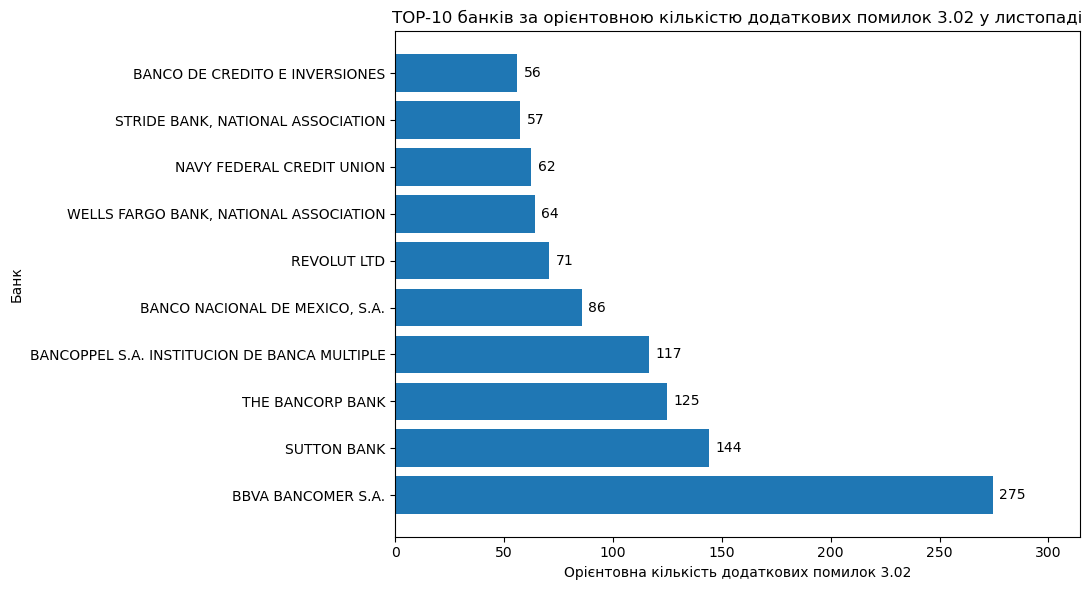

In [91]:
top10_bank_bar = bank_month_analysis20.sort_values(by = 'additional_302',ascending = False).head(10)

plt.figure(figsize=(11, 6))

bars = plt.barh(
    top10_bank_bar.index,
    top10_bank_bar['additional_302'])

plt.title('TOP-10 банків за орієнтовною кількістю додаткових помилок 3.02 у листопаді')
plt.xlabel('Орієнтовна кількість додаткових помилок 3.02')
plt.ylabel('Банк')

for bar in bars:
    width = bar.get_width()

    plt.text(
        width + 3,
        bar.get_y() + bar.get_height() / 2,
        f'{width:.0f}',
        va='center')

plt.xlim(0, top10_bank_bar['additional_302'].max() + 40)

plt.tight_layout()
plt.show()

**Висновок.** Найвищу орієнтовну оцінку має **BBVA BANCOMER S.A. — близько 275 додаткових помилок** порівняно зі сценарієм незмінного жовтневого Error Rate.

Також виділяються **SUTTON BANK, THE BANCORP BANK та BANCOPPEL**. Великий платіжний потік може давати суттєву кількість додаткових відмов навіть за відносно невеликого приросту частоти.

Для оцінки масштабу враховуємо **і зміну Error Rate, і кількість recurrent-платежів**.

### Груднева динаміка 3.02 у листопадному TOP-10

Перевіряємо `dec_mom` для тих самих банків:

- `dec_mom < 0` — частота `3.02` знизилася.
- `dec_mom > 0` — частота `3.02` зросла.

Зіставляємо грудневу динаміку цього коду з листопадним зростанням.

In [92]:
top10_bank_bar[['nov_mom','dec_mom']].sort_values(by = 'dec_mom',ascending = True)

,nov_mom,dec_mom
bank_name,,
SUTTON BANK,1.81,-55.37
"STRIDE BANK, NATIONAL ASSOCIATION",6.19,-52.15
BANCO DE CREDITO E INVERSIONES,10.08,-26.88
"BANCO NACIONAL DE MEXICO, S.A.",26.30,-6.13
THE BANCORP BANK,9.11,-5.38
REVOLUT LTD,10.08,-5.05
"WELLS FARGO BANK, NATIONAL ASSOCIATION",5.49,-2.86
NAVY FEDERAL CREDIT UNION,11.29,-1.33
BBVA BANCOMER S.A.,18.70,4.79


**Висновок.** У **8 із 10 банків** листопадного TOP-10 частота `3.02` у грудні знизилася.

Найбільше зниження Error Rate `3.02`:

- **SUTTON BANK: −55,37 п.п.**
- **STRIDE BANK, NATIONAL ASSOCIATION: −52,15 п.п.**

Водночас у **BBVA BANCOMER S.A. (+4,79 п.п.)** та **BANCOPPEL (+8,12 п.п.)** частота цього коду продовжила зростати.

### Квітень і травень: оцінка додаткових помилок 3.02

За тією самою логікою порівнюємо березень, квітень і травень. Для квітня та травня розраховуємо зміну Error Rate відносно попереднього місяця та `additional_302`, після чого відбираємо TOP-10 банків із додатною зміною.

In [93]:
month_bank_stats_KV_TR = bank_302_stats_month_500[(bank_302_stats_month_500['month_per'] == '2022-03') | 
(bank_302_stats_month_500['month_per'] == '2022-04') | (bank_302_stats_month_500['month_per'] == '2022-05')].copy()

In [94]:
bank_month_analysis_KV_TR = pd.pivot_table(
    month_bank_stats_KV_TR,
    index='bank_name',
    columns='month_per',
    values=['error_rate_302', 'total_recurrent', 'cnt_302'])

In [95]:
bank_month_analysis_KV_TR['kvit_mom'] = (bank_month_analysis_KV_TR[('error_rate_302', '2022-04')] - bank_month_analysis_KV_TR[('error_rate_302', '2022-03')])
bank_month_analysis_KV_TR['trav_mom'] = (bank_month_analysis_KV_TR[('error_rate_302', '2022-05')] - bank_month_analysis_KV_TR[('error_rate_302', '2022-04')])


In [96]:
bank_month_analysis_KV_TR.columns = [
    f'{metric}_{month}' if pd.notna(month) else metric
    for metric, month in bank_month_analysis_KV_TR.columns]

In [97]:
bank_month_analysis_KV_TR

,cnt_302_2022-03,cnt_302_2022-04,cnt_302_2022-05,error_rate_302_2022-03,error_rate_302_2022-04,error_rate_302_2022-05,total_recurrent_2022-03,total_recurrent_2022-04,total_recurrent_2022-05,kvit_mom,trav_mom
bank_name,,,,,,,,,,,
ABSA BANK LIMITED,8.0,5.0,5.0,28.57,22.73,18.52,28.0,22.0,27.0,-5.84,-4.21
ABU DHABI COMMERCIAL BANK,0.0,3.0,0.0,0.00,10.00,0.00,32.0,30.0,20.0,10.00,-10.00
AMERICAN EXPRESS COMPANY,0.0,0.0,0.0,0.00,0.00,0.00,45.0,90.0,95.0,0.00,0.00
ANZ BANK NEW ZEALAND LIMITED,12.0,26.0,30.0,17.39,23.21,23.44,69.0,112.0,128.0,5.82,0.23
ASB BANK,21.0,36.0,22.0,32.31,44.44,26.83,65.0,81.0,82.0,12.13,-17.61
...,...,...,...,...,...,...,...,...,...,...,...
"WELLS FARGO BANK, NATIONAL ASSOCIATION",55.0,58.0,145.0,9.93,9.54,16.35,554.0,608.0,887.0,-0.39,6.81
WESTPAC BANKING CORPORATION,30.0,67.0,131.0,25.42,36.81,49.25,118.0,182.0,266.0,11.39,12.44
WESTPAC NEW ZEALAND LIMITED,7.0,14.0,22.0,16.28,29.79,35.48,43.0,47.0,62.0,13.51,5.69


In [98]:
bank_month_analysis_KV_TR_fil = bank_month_analysis_KV_TR[[
    'error_rate_302_2022-03',
    'error_rate_302_2022-04',
    'kvit_mom',
    'total_recurrent_2022-04',
    'cnt_302_2022-04',

    'error_rate_302_2022-05',
    'trav_mom',
    'total_recurrent_2022-05',
    'cnt_302_2022-05']].copy()

In [99]:
bank_month_analysis_KV_TR_fil['additional_302_apr'] = (
    bank_month_analysis_KV_TR_fil['total_recurrent_2022-04']
    * bank_month_analysis_KV_TR_fil['kvit_mom']) / 100

bank_month_analysis_KV_TR_fil['additional_302_may'] = (
    bank_month_analysis_KV_TR_fil['total_recurrent_2022-05']
    * bank_month_analysis_KV_TR_fil['trav_mom']) / 100

In [100]:
top10_apr = (bank_month_analysis_KV_TR_fil[bank_month_analysis_KV_TR_fil['kvit_mom'] > 0]
             .sort_values(by='additional_302_apr', ascending=False).head(10))

top10_apr

,error_rate_302_2022-03,error_rate_302_2022-04,kvit_mom,total_recurrent_2022-04,cnt_302_2022-04,error_rate_302_2022-05,trav_mom,total_recurrent_2022-05,cnt_302_2022-05,additional_302_apr,additional_302_may
bank_name,,,,,,,,,,,
AUSTRALIA AND NEW ZEALAND BANKING GROUP LIMITED,22.78,40.38,17.60,260.0,105.0,31.14,-9.24,273.0,85.0,45.7600,-25.2252
COMMONWEALTH BANK OF AUSTRALIA,32.84,38.00,5.16,671.0,255.0,44.54,6.54,907.0,404.0,34.6236,59.3178
BANK OF NEW ZEALAND,15.00,62.00,47.00,50.0,31.0,56.06,-5.94,66.0,37.0,23.5000,-3.9204
BANCA TRANSILVANIA S.A.,13.33,54.39,41.06,57.0,31.0,36.73,-17.66,49.0,18.0,23.4042,-8.6534
ROYAL BANK OF CANADA,13.00,21.64,8.64,268.0,58.0,20.48,-1.16,293.0,60.0,23.1552,-3.3988
THE BANCORP BANK,47.98,51.79,3.81,585.0,303.0,48.78,-3.01,861.0,420.0,22.2885,-25.9161
WESTPAC BANKING CORPORATION,25.42,36.81,11.39,182.0,67.0,49.25,12.44,266.0,131.0,20.7298,33.0904
BANK OF MONTREAL,14.85,27.85,13.00,158.0,44.0,45.92,18.07,196.0,90.0,20.5400,35.4172
FIRST PREMIER BANK,37.84,61.90,24.06,84.0,52.0,54.76,-7.14,84.0,46.0,20.2104,-5.9976


In [101]:
top10_may = (bank_month_analysis_KV_TR_fil[bank_month_analysis_KV_TR_fil['trav_mom'] > 0]
    .sort_values(by='additional_302_may', ascending=False).head(10))

top10_may

,error_rate_302_2022-03,error_rate_302_2022-04,kvit_mom,total_recurrent_2022-04,cnt_302_2022-04,error_rate_302_2022-05,trav_mom,total_recurrent_2022-05,cnt_302_2022-05,additional_302_apr,additional_302_may
bank_name,,,,,,,,,,,
"CAPITAL ONE BANK (USA), NATIONAL ASSOCIATION",18.96,23.66,4.70,355.0,84.0,45.50,21.84,556.0,253.0,16.6850,121.4304
"WELLS FARGO BANK, NATIONAL ASSOCIATION",9.93,9.54,-0.39,608.0,58.0,16.35,6.81,887.0,145.0,-2.3712,60.4047
COMMONWEALTH BANK OF AUSTRALIA,32.84,38.00,5.16,671.0,255.0,44.54,6.54,907.0,404.0,34.6236,59.3178
"METABANK, NATIONAL ASSOCIATION",50.00,53.80,3.80,316.0,170.0,65.60,11.80,407.0,267.0,12.0080,48.0260
BANK OF MONTREAL,14.85,27.85,13.00,158.0,44.0,45.92,18.07,196.0,90.0,20.5400,35.4172
WESTPAC BANKING CORPORATION,25.42,36.81,11.39,182.0,67.0,49.25,12.44,266.0,131.0,20.7298,33.0904
"MVB BANK, INC",57.78,61.58,3.80,190.0,117.0,74.17,12.59,240.0,178.0,7.2200,30.2160
THE BANK OF NOVA SCOTIA,23.18,21.50,-1.68,200.0,43.0,30.94,9.44,320.0,99.0,-3.3600,30.2080
JPMORGAN CHASE BANK N.A.,0.00,0.00,0.00,189.0,0.0,7.02,7.02,342.0,24.0,0.0000,24.0084


### Перетини TOP-10 банків у різні місяці

Порівнюємо назви банків із квітневого, травневого та листопадного TOP-10. Перевіряємо попарні перетини та спільні банки для всіх трьох місяців.

In [102]:
apr_banks = set(top10_apr.index)
may_banks = set(top10_may.index)
nov_banks = set(top10_bank_bar.index)

In [103]:
apr_may = apr_banks & may_banks
apr_nov = apr_banks & nov_banks
may_nov = may_banks & nov_banks
all_three = apr_banks & may_banks & nov_banks

In [104]:
print('April & May:', apr_may)
print('April & November:', apr_nov)
print('May & November:', may_nov)
print('All three:', all_three)

April & May: {'COMMONWEALTH BANK OF AUSTRALIA', 'WESTPAC BANKING CORPORATION', 'BANK OF MONTREAL'}
April & November: {'THE BANCORP BANK', 'STRIDE BANK, NATIONAL ASSOCIATION'}
May & November: {'WELLS FARGO BANK, NATIONAL ASSOCIATION'}
All three: set()


**Висновок.** Помилка `3.02` повторювалася в різні періоди, але склад банків із найбільшими оцінками додаткових відмов змінювався.

**Жоден банк не потрапив до TOP-10 одночасно у квітні, травні та листопаді.** Попарні перетини:

- **Квітень–травень:** WESTPAC BANKING CORPORATION; COMMONWEALTH BANK OF AUSTRALIA; BANK OF MONTREAL.
- **Квітень–листопад:** THE BANCORP BANK; STRIDE BANK, NATIONAL ASSOCIATION.
- **Травень–листопад:** WELLS FARGO BANK, NATIONAL ASSOCIATION.

Основні банківські групи, що виділялися за цим показником, змінювалися протягом року.

## 8. Вплив помилки 3.02 на користувачів

**Що досліджуємо:** скільки користувачів отримали recurrent fail `3.02`, як часто помилка повторювалася та які recurrent-платежі були після неї.

In [105]:
df

,order_id,event_time,user_id,price,payment_number,transaction_status,card_brand,card_type,bank_name,error_type,currency,card_country,month,month_per
0,c500aa10-30f8-4927-96c5-4e97b6afac83,2022-07-08 18:32:39,c1ed5188-caac-4d56-bad8-bc8ee0b09960,21.0,reccurent,fail,VISA,PREPAID,ADVANCED BANK OF ASIA LIMITED,3.08,USD,KHM,July,2022-07
1,624d6f30-c1bc-4778-a23e-6a227bac73ac,2022-06-09 22:18:36,c9ff65b8-75e6-467f-8715-21edb5fd06af,36.0,reccurent,fail,VISA,PREPAID,UNITED BANK FOR AFRICA GHANA LIMITED,3.02,USD,GHA,June,2022-06
2,4d75ca57-8883-49a9-b150-1ab7a47d12f8,2022-06-09 11:18:32,1005d4fb-1b7d-4715-835f-4d2a9bfe7cbb,36.0,initial,success,VISA,CREDIT,ICICI BANK LTD,NaN,USD,IND,June,2022-06
3,3fd11eed-4236-46aa-8f21-3c1e1a17a1bc,2022-06-29 13:50:47,866c4b2b-0285-43aa-98bd-d60bc3a78d7c,36.0,reccurent,fail,VISA,DEBIT,THE TORONTO-DOMINION BANK,3.02,USD,CAN,June,2022-06
4,3b19657f-1a34-4233-b25c-5d3b7fb32782,2022-06-17 15:16:47,bd2e4137-5526-4d9b-9dde-7482087fc321,9.0,reccurent,success,MASTERCARD,CREDIT,"CAPITAL ONE BANK (USA), NATIONAL ASSOCIATION",NaN,USD,USA,June,2022-06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
566408,1a5a6077-bf0a-4a21-bb51-4e0a5f0ef689,2022-04-14 13:23:13,6eb098dd-e479-4f02-be02-74ed1ecc0551,12.0,initial,success,VISA,DEBIT,"WELLS FARGO BANK, NATIONAL ASSOCIATION",NaN,USD,USA,April,2022-04
566409,276d6270-b665-4b72-bb90-d9d3ef1fc571,2022-04-17 16:14:47,921e4a74-9407-4d84-92f7-1f58750f77c5,24.0,reccurent,success,MASTERCARD,CREDIT,COLLABRIA FINANCIAL SERVICES,NaN,USD,CAN,April,2022-04
566410,8dde4932-ec01-4ffa-88e0-f8689aaad00e,2022-01-03 08:12:47,d8be2270-2337-4f5c-b695-0177bc351915,21.0,reccurent,success,VISA,DEBIT,BANK OF SCOTLAND PLC,NaN,USD,GBR,January,2022-01
566411,372312ea-3132-4999-b2da-7a8542aa8627,2022-05-01 12:47:47,61819e8e-12e5-4725-bf7c-e02f8d34b3ad,9.0,reccurent,success,VISA,DEBIT,TRUIST BANK,NaN,USD,USA,May,2022-05


In [106]:
filt_for_user = df[(df['payment_number'] == 'reccurent') & (df['transaction_status'] == 'fail') & (df['error_type'] == 3.02)]

filt_for_user['user_id'].nunique()

25987

**Висновок.** З recurrent fail `3.02` зіткнулися **25 987 унікальних користувачів**. Проблема має значний масштаб не лише за кількістю транзакцій, а й за кількістю користувачів.

### Повторюваність помилки на рівні користувача

Рахуємо кількість recurrent fail `3.02` для кожного користувача та переглядаємо описову статистику.

In [107]:
rozpodil_users = filt_for_user.groupby('user_id').size().reset_index(name = 'cnt')

rozpodil_users.describe()

,cnt
count,25987.000000
mean,4.657367
std,3.307092
min,1.000000
25%,2.000000
50%,5.000000
75%,5.000000
max,34.000000


**Висновок.** Кількість `3.02` на одного користувача:

- **Середнє — близько 4,66.**
- **Медіана — 5.**
- **Максимум — 34.**

Для частини користувачів помилка мала повторюваний характер.

**Розподіл кількості помилок.** Визначаємо, скільки користувачів отримали `3.02` певну кількість разів.

In [108]:
rozpodil_users['cnt'].value_counts().reset_index(name = 'cnt_users')

,cnt,cnt_users
0,5,7289
1,1,4057
2,2,3658
3,4,2538
4,3,2125
5,6,1725
6,7,1022
7,8,808
8,9,752
9,10,697


**Висновок.** Найбільша група — **7 289 користувачів, які отримали `3.02` рівно 5 разів**.

Концентрація може свідчити про системну логіку повторних спроб. Для перевірки цієї гіпотези потрібно дослідити зв'язок між операціями на рівні замовлення та часу.

### Recurrent-платежі після першої помилки 3.02

Знаходимо час першої `3.02` для кожного користувача, приєднуємо його до recurrent-платежів і залишаємо операції, що відбулися пізніше.

In [109]:
first_302 = filt_for_user.groupby('user_id')['event_time'].min().reset_index(name ='first_302_time')

table_recuren_df = df[df['payment_number'] == 'reccurent']

table_recuren_df_302 = table_recuren_df.merge(
    first_302,
    on = 'user_id',
    how = 'inner') 

table_recuren_df_302_fil = table_recuren_df_302[table_recuren_df_302['event_time'] > table_recuren_df_302['first_302_time']]

table_recuren_df_302_fil

,order_id,event_time,user_id,price,payment_number,transaction_status,card_brand,card_type,bank_name,error_type,currency,card_country,month,month_per,first_302_time
0,624d6f30-c1bc-4778-a23e-6a227bac73ac,2022-06-09 22:18:36,c9ff65b8-75e6-467f-8715-21edb5fd06af,36.0,reccurent,fail,VISA,PREPAID,UNITED BANK FOR AFRICA GHANA LIMITED,3.02,USD,GHA,June,2022-06,2022-06-08 22:17:47
3,0247dd82-e02b-4eab-9a42-37fb1b439141,2022-06-03 15:20:37,d251f347-f0c3-47a0-b4e9-2e2269c67d8e,20.0,reccurent,success,MASTERCARD,CREDIT,ALIOR BANK SPOLKA AKCYJNA,NaN,EUR,ROU,June,2022-06,2022-05-22 15:19:47
4,7911d07e-aa1a-43ec-b141-aa8745d58c03,2022-07-08 13:59:37,a23e0c95-ccf0-4d05-b0b0-a1dd889726bb,20.0,reccurent,fail,MASTERCARD,CREDIT,"BANCO DAVIVIENDA, S.A.",3.03,USD,COL,July,2022-07,2022-06-24 13:58:50
5,fec9af78-0c7b-4e74-8101-a2d216978574,2022-06-19 11:12:36,eab2fa52-8991-4aaa-9142-46b46d828576,28.0,reccurent,fail,MASTERCARD,DEBIT,COMMONWEALTH BANK OF AUSTRALIA,3.02,USD,AUS,June,2022-06,2022-04-08 11:11:47
6,0b500c9b-5d7d-472e-b3bd-91105a1f2abd,2022-06-17 23:17:36,fddbb01f-49b6-4bdc-8543-3646ff1edfdd,36.0,reccurent,fail,VISA,DEBIT,ING BANK (AUSTRALIA) LIMITED,3.02,USD,AUS,June,2022-06,2022-06-05 23:17:05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
227270,7ad1bb52-485f-4ce2-8634-05bcf3a89ee7,2022-05-27 10:35:36,c2f3b455-4ab6-4b4c-9cc3-804554ae68fc,36.0,reccurent,fail,MASTERCARD,DEBIT,WESTPAC NEW ZEALAND LIMITED,3.02,USD,NZL,May,2022-05,2022-05-22 10:35:47
227272,0490b9eb-0953-4b9e-a24f-bb3cc368c9ff,2022-04-01 18:35:47,83503c67-cccc-4432-9891-ddcf379243ff,21.0,reccurent,success,VISA,DEBIT,BANK OF SCOTLAND PLC,NaN,USD,GBR,April,2022-04,2022-01-21 18:43:47
227273,2dbbb300-73a9-4795-ba4e-9b2ebff07eed,2022-04-17 09:24:36,53d3a903-3f2f-4ae0-8f0c-6c2051649df3,36.0,reccurent,fail,VISA,DEBIT,USAA FEDERAL SAVINGS BANK,3.02,USD,USA,April,2022-04,2022-04-16 09:23:47
227276,d32eb627-ed70-47a0-9174-38e56940623c,2022-05-06 13:15:37,e3677eed-d316-4422-a9d9-1c863cf0247c,55.0,reccurent,fail,MASTERCARD,DEBIT,ERSTE BANK A.D. PODGORICA,3.02,USD,MNE,May,2022-05,2022-04-04 13:16:48


**Що зроблено.** Для кожного користувача визначено час першої `3.02`. У таблиці залишено лише recurrent-платежі після цього моменту, щоб дослідити подальший результат оплати.

**Наступний успішний платіж.** Відбираємо користувачів, які після першої `3.02` мали хоча б один успішний recurrent-платіж.

In [110]:
table_recuren_df_302_fil_sec = table_recuren_df_302_fil[table_recuren_df_302_fil['transaction_status'] == 'success']

In [111]:
table_recuren_df_302_fil_sec['user_id'].nunique()

10967

**Результат.** Після першої `3.02` **10 967 користувачів** надалі мали хоча б один успішний recurrent-платіж.

**Наявність подальших спроб.** Рахуємо всіх користувачів, які мали recurrent-платежі після першої `3.02`, незалежно від їхнього статусу.

In [112]:
table_recuren_df_302_fil['user_id'].nunique()

24831

Показник вище — кількість унікальних користувачів із **хоча б однією recurrent-спробою після першої `3.02`**.

**Подальші спроби без успіху.** Із кількості користувачів із подальшими спробами віднімаємо тих, хто мав наступний success.

In [113]:
table_recuren_df_302_fil['user_id'].nunique() - table_recuren_df_302_fil_sec['user_id'].nunique()

13864

**Результат.** **13 864 користувачі** після першої `3.02` продовжили recurrent-спроби, але не мали наступного успішного recurrent-платежу.

**Відсутність подальших спроб.** Із усіх користувачів із `3.02` віднімаємо тих, хто мав хоча б одну наступну recurrent-спробу.

In [114]:
filt_for_user['user_id'].nunique() - table_recuren_df_302_fil['user_id'].nunique()

1156

Показник вище — кількість користувачів, у яких після першої `3.02` **не було наступних recurrent-спроб у межах доступних даних**.

### Підсумок подальших результатів користувачів

Зводимо три групи в підсумкову таблицю, визначаємо їхні частки та показуємо результати на горизонтальній діаграмі.

In [115]:
user_302_summary = pd.DataFrame({
    'result': [
        'Успішна оплата',
        'Повторні спроби без успіху',
        'Повторних спроб не було'],
    'users': [
        10967,
        13864,
        1156]})

user_302_summary['share_%'] = (user_302_summary['users'] / user_302_summary['users'].sum() * 100).round(2)

user_302_summary

,result,users,share_%
0,Успішна оплата,10967,42.20
1,Повторні спроби без успіху,13864,53.35
2,Повторних спроб не було,1156,4.45


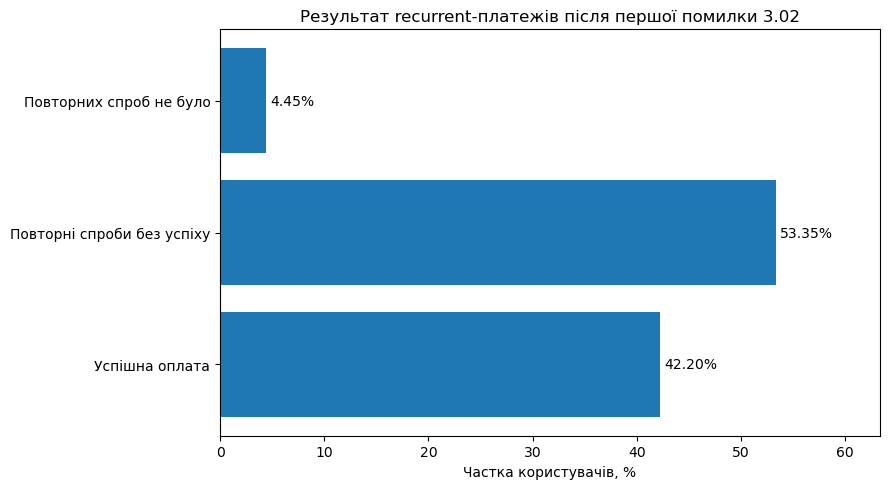

In [116]:
fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.barh(
    user_302_summary['result'],
    user_302_summary['share_%'])

ax.bar_label(
    bars,
    fmt='%.2f%%',
    padding=3)

ax.set_title('Результат recurrent-платежів після першої помилки 3.02')
ax.set_xlabel('Частка користувачів, %')
ax.set_ylabel('')

ax.set_xlim(0, user_302_summary['share_%'].max() + 10)

plt.tight_layout()
plt.show()

**Висновок.** Після першої `3.02`:

- **42,20%** користувачів надалі мали хоча б один успішний recurrent-платіж.
- **53,35%** продовжували recurrent-спроби, але не мали наступного success.
- **4,45%** більше не мали recurrent-спроб у межах доступних даних.

Помилка `3.02` мала суттєвий користувацький масштаб: для значної частини користувачів подальші спроби не завершилися зафіксованим успішним платежем.

## 9. Загальні висновки

У роботі я проаналізував платіжні спроби за 2022 рік, їхню успішність та помилки recurrent-платежів. Основні результати:

1. **Понад половина спроб завершилася відмовою.** Після очищення залишилось **565 315 спроб від 115 245 користувачів**. Загальний Success Rate — **44,47%**.

2. **Успішність платежів загалом знижувалася.** Найвищий SR був у лютому — **57,7%**, найнижчий у листопаді — **37,3%**. У грудні він відновився до **46,8%**, але не досяг рівня початку року.

3. **Найбільше погіршення видно в recurrent-платежах.** Їхній SR знизився приблизно з **61%** на початку року до **33%** у листопаді. Водночас initial загалом покращувався. Оскільки recurrent формували більшість спроб, їхня динаміка суттєва для загального результату.

4. **Найчастіший recurrent-код — `3.02`: близько 51,25% відмов.** Його частота особливо зростала у квітні, травні та листопаді. Проте всю негативну динаміку не можна пояснити лише ним: у різні місяці виділялися й інші коди.

5. **Склад банків у TOP-10 змінювався.** Жоден банк не входив до TOP-10 за оцінкою додаткових `3.02` одночасно у квітні, травні та листопаді. Тому банківські показники потрібно розглядати в динаміці, враховуючи частоту помилок та обсяг платежів.

6. **Помилка `3.02` зачепила 25 987 користувачів.** Після її першої появи **42,20%** надалі мали успішний recurrent-платіж, **53,35%** продовжували спроби без успіху, а **4,45%** не мали наступних recurrent-спроб у межах доступних даних.

## 10. Рекомендації

На основі отриманих результатів я пропоную:

1. **Відстежувати initial і recurrent окремо.** Порівнювати їхній місячний SR разом із кількістю та часткою спроб, щоб вчасно помічати погіршення.

2. **Насамперед дослідити код `3.02`.** Уточнити його значення з платіжною командою та перевірити причини зростання частоти у квітні, травні й листопаді. Також стежити за іншими основними кодами.

3. **Контролювати зміни за банками.** Почати з банків, які потрапили до TOP-10 у проблемні місяці. Порівнювати Error Rate одночасно з кількістю спроб і відмов.

4. **Перевірити логіку повторних спроб.** З'ясувати, чому **7 289 користувачів отримали `3.02` рівно п'ять разів**: переглянути час операцій та їхній зв'язок із замовленнями.

5. **Окремо розглянути користувачів із повторними відмовами без успіху.** Перевірити коди їхніх наступних помилок і умови повторних спроб, щоб визначити, що заважає завершити оплату.